# Phase 1A: Reach-Avoid vs ELBO Ranking Analysis (Cancer)

Zero-retraining experiments on existing VCIP models (Cancer, 4 gammas × 5 seeds).

**Key innovation:** RA scores computed offline from saved trajectory features (`traj_features`), allowing threshold exploration without re-running GPU evaluation.

**Experiments:**
- E1: Ranking comparison — RA vs ELBO Top-1 agreement on Cancer ground truth
- E2: Margin analysis — pairwise margin distributions (validates T2 theorem)
- E3: Cross-seed ranking stability (Cancer only; MIMIC deferred to Phase 1B)

**Decision gate:** If RA scoring does not substantially improve Top-1 agreement over ELBO on Cancer ground truth, reassess before Phase 2.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, rankdata
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.2)
%matplotlib inline

## Offline RA Scoring Engine

Compute reach-avoid scores from saved trajectory features (`cv_terminal`, `cv_max`, `cd_max`) with arbitrary thresholds. This avoids re-running GPU evaluation when tuning thresholds.

In [2]:
def soft_indicator_upper(y, upper, kappa=10.0):
    """σ(κ·(upper - y)): ≈1 when y < upper, ≈0 when y > upper."""
    return 1.0 / (1.0 + np.exp(-np.clip(kappa * (upper - y), -500, 500)))

def compute_ra_scores_offline(traj_features, target_upper, safety_volume_upper=None,
                               safety_chemo_upper=None, kappa=10.0):
    """Compute RA scores from saved per-sequence trajectory features."""
    cv_terminal = traj_features['cv_terminal']
    cv_max = traj_features['cv_max']
    cd_max = traj_features['cd_max']
    
    g_target = soft_indicator_upper(cv_terminal, target_upper, kappa)
    
    g_safety_vol = soft_indicator_upper(cv_max, safety_volume_upper, kappa) \
        if safety_volume_upper is not None else 1.0
    
    g_safety_chemo = soft_indicator_upper(cd_max, safety_chemo_upper, kappa) \
        if safety_chemo_upper is not None else 1.0
    
    combined = g_target * g_safety_vol * g_safety_chemo
    ra_scores = np.log(np.clip(combined, 1e-30, None))
    
    return ra_scores

# --- Data loading ---
PROJECT_ROOT = Path('/Users/anisiomlacerda/code/target-counterfactual')
RESULTS_BASE = PROJECT_ROOT / 'results_remote' / 'phase1_ra_v2' / 'my_outputs' / 'cancer_sim_cont' / '22'

SEEDS = [10, 101, 1010, 10101, 101010]
GAMMAS = [1, 2, 3, 4]
TAUS = [2, 4, 6, 8]
K = 100

all_data = {}
for gamma in GAMMAS:
    all_data[gamma] = {}
    for seed in SEEDS:
        pkl_path = (RESULTS_BASE / f'coeff_{gamma}' / 'VCIP' / 'train' / 'True' /
                    'case_infos' / str(seed) / 'False' / 'case_infos_VCIP.pkl')
        if pkl_path.exists():
            with open(pkl_path, 'rb') as f:
                data = pickle.load(f)
            all_data[gamma][seed] = data['VCIP']
        else:
            print(f'Missing: gamma={gamma}, seed={seed}')

# Summary
for gamma in GAMMAS:
    n_seeds = len(all_data[gamma])
    if n_seeds > 0:
        sample_seed = list(all_data[gamma].keys())[0]
        taus_found = list(all_data[gamma][sample_seed].keys())
        n_ind = len(all_data[gamma][sample_seed][taus_found[0]])
        print(f'gamma={gamma}: {n_seeds} seeds, taus={taus_found}, {n_ind} individuals/tau')

# Verify traj_features
sample_ci = all_data[4][10][2][0]
has_traj = 'traj_features' in sample_ci
print(f'\ntraj_features present: {has_traj}')
print(f'Case info keys: {sorted(sample_ci.keys())}')

gamma=1: 5 seeds, taus=[2, 4, 6, 8], 100 individuals/tau
gamma=2: 5 seeds, taus=[2, 4, 6, 8], 100 individuals/tau
gamma=3: 5 seeds, taus=[2, 4, 6, 8], 100 individuals/tau
gamma=4: 5 seeds, taus=[2, 4, 6, 8], 100 individuals/tau

traj_features present: True
Case info keys: ['all_sequences', 'correlations', 'individual_id', 'model_losses', 'traj_features', 'true_losses', 'true_sequence', 'true_sequence_rank']


## Threshold Exploration

Sweep across threshold configurations to find which produces the best RA discrimination. 
The key metric is **Top-1 agreement**: does RA's best-scoring sequence match the ground-truth best?

We also check **RA discrimination**: fraction of sequences with non-degenerate RA scores (not all identical).

In [3]:
# Threshold sweep: find configuration that maximizes RA Top-1 agreement
# Use gamma=4, tau=2 as development set (most confounding, shortest horizon)

target_uppers = [0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0]
safety_vol_uppers = [0.5, 1.0, 2.0, 5.0, 10.0, None]  # None = disabled
safety_chemo_uppers = [5.0, 7.0, 8.0, 9.0, None]  # None = disabled
kappas = [5.0, 10.0, 20.0]

def evaluate_threshold_config(target_upper, safety_vol, safety_chemo, kappa,
                                gamma=4, tau=2):
    """Quick evaluation: compute RA Top-1 and discrimination for one config."""
    top1_hits = 0
    total = 0
    n_discriminating = 0  # individuals where RA scores are not all identical
    
    for seed in all_data[gamma]:
        if tau not in all_data[gamma][seed]:
            continue
        for ci in all_data[gamma][seed][tau]:
            if 'traj_features' not in ci:
                continue
            ra = compute_ra_scores_offline(
                ci['traj_features'], target_upper, safety_vol, safety_chemo, kappa)
            
            # Check discrimination
            if len(np.unique(np.round(ra, 4))) > 1:
                n_discriminating += 1
            
            # Top-1: does RA's best match ground-truth best?
            best_ra_idx = np.argmax(ra)
            best_true_idx = np.argmin(ci['true_losses'])
            if best_ra_idx == best_true_idx:
                top1_hits += 1
            total += 1
    
    return {
        'top1': top1_hits / total if total > 0 else 0,
        'discrimination': n_discriminating / total if total > 0 else 0,
        'n': total,
    }

# Run sweep
print('=== Threshold Sweep (gamma=4, tau=2) ===')
print(f'{"target":>8} {"safe_vol":>8} {"safe_chm":>8} {"kappa":>6} | {"Top1":>6} {"Discr":>6}')
print('-' * 60)

sweep_results = []
for target in target_uppers:
    for sv in safety_vol_uppers:
        for sc in safety_chemo_uppers:
            for kappa in kappas:
                res = evaluate_threshold_config(target, sv, sc, kappa)
                res.update({'target': target, 'safety_vol': sv, 'safety_chemo': sc, 'kappa': kappa})
                sweep_results.append(res)

df_sweep = pd.DataFrame(sweep_results)

# Show top 20 configs by Top-1
df_sweep_sorted = df_sweep.sort_values('top1', ascending=False).head(20)
for _, row in df_sweep_sorted.iterrows():
    sv_str = f'{row["safety_vol"]:.1f}' if row['safety_vol'] is not None else 'None'
    sc_str = f'{row["safety_chemo"]:.1f}' if row['safety_chemo'] is not None else 'None'
    print(f'{row["target"]:8.2f} {sv_str:>8} {sc_str:>8} {row["kappa"]:6.1f} | '
          f'{row["top1"]:6.3f} {row["discrimination"]:6.3f}')

=== Threshold Sweep (gamma=4, tau=2) ===
  target safe_vol safe_chm  kappa |   Top1  Discr
------------------------------------------------------------


    5.00     10.0      9.0   20.0 |  0.018  0.122
    5.00      nan      9.0   20.0 |  0.018  0.126
    5.00      2.0      9.0   20.0 |  0.018  0.248
    5.00      5.0      9.0   20.0 |  0.018  0.114
    5.00      nan      nan   20.0 |  0.016  0.076
    2.00      2.0      nan   20.0 |  0.016  0.228
    2.00     10.0      9.0   20.0 |  0.016  0.302
    5.00      5.0      nan   10.0 |  0.016  0.098
    2.00      5.0      nan   20.0 |  0.016  0.262
    5.00      5.0      nan   20.0 |  0.016  0.064
    5.00      nan      8.0   20.0 |  0.016  0.776
    2.00      5.0      9.0   20.0 |  0.016  0.294
    5.00      nan      8.0   10.0 |  0.016  0.992
    2.00      2.0      9.0   20.0 |  0.016  0.260
    2.00     10.0      nan   20.0 |  0.016  0.270
    5.00      nan      7.0   20.0 |  0.016  0.988
    5.00      2.0      nan   20.0 |  0.016  0.204
    5.00     10.0      7.0   20.0 |  0.016  0.984
    5.00     10.0      8.0   10.0 |  0.016  0.986
    5.00     10.0      8.0   20.0 |  0.016  0.772


In [4]:
# Select best threshold config and apply RA scores to all data
best = df_sweep.sort_values('top1', ascending=False).iloc[0]
BEST_TARGET = best['target']
BEST_SAFETY_VOL = best['safety_vol']
BEST_SAFETY_CHEMO = best['safety_chemo']
BEST_KAPPA = best['kappa']

print(f'Selected threshold config:')
print(f'  target_upper = {BEST_TARGET}')
print(f'  safety_volume_upper = {BEST_SAFETY_VOL}')
print(f'  safety_chemo_upper = {BEST_SAFETY_CHEMO}')
print(f'  kappa = {BEST_KAPPA}')
print(f'  Top-1 (dev set, gamma=4 tau=2) = {best["top1"]:.3f}')
print(f'  Discrimination = {best["discrimination"]:.3f}')

# Also get ELBO baseline Top-1 for gamma=4, tau=2
elbo_top1_hits = 0
elbo_total = 0
for seed in all_data[4]:
    if 2 not in all_data[4][seed]:
        continue
    for ci in all_data[4][seed][2]:
        best_elbo_idx = np.argmin(ci['model_losses'])  # lower ELBO = better in VCIP
        best_true_idx = np.argmin(ci['true_losses'])
        if best_elbo_idx == best_true_idx:
            elbo_top1_hits += 1
        elbo_total += 1
print(f'\nELBO baseline Top-1 (gamma=4, tau=2) = {elbo_top1_hits/elbo_total:.3f}')

# Augment all case_infos with RA scores using best thresholds
n_augmented = 0
for gamma in GAMMAS:
    for seed in all_data[gamma]:
        for tau in all_data[gamma][seed]:
            for ci in all_data[gamma][seed][tau]:
                if 'traj_features' in ci:
                    ci['ra_scores'] = compute_ra_scores_offline(
                        ci['traj_features'], BEST_TARGET, BEST_SAFETY_VOL,
                        BEST_SAFETY_CHEMO, BEST_KAPPA)
                    n_augmented += 1

print(f'\nAugmented {n_augmented} case_infos with RA scores.')

Selected threshold config:
  target_upper = 5.0
  safety_volume_upper = 10.0
  safety_chemo_upper = 9.0
  kappa = 20.0
  Top-1 (dev set, gamma=4 tau=2) = 0.018
  Discrimination = 0.122

ELBO baseline Top-1 (gamma=4, tau=2) = 0.188

Augmented 8000 case_infos with RA scores.


In [5]:
def compute_ranking_metrics(case_infos, has_ra=True):
    """Compute ranking quality metrics for ELBO and RA scoring."""
    results = []
    for ci in case_infos:
        k = len(ci['model_losses'])
        
        # Ground truth: lower true_loss = better
        true_ranks = rankdata(ci['true_losses'])
        best_true_idx = np.argmin(ci['true_losses'])
        
        # ELBO ranking: lower model_losses = better (VCIP convention)
        best_elbo_idx = np.argmin(ci['model_losses'])
        elbo_top1 = int(best_elbo_idx == best_true_idx)
        elbo_true_rho, _ = spearmanr(ci['model_losses'], ci['true_losses'])
        elbo_grp = 1 - (ci['true_sequence_rank'] - 1) / k
        
        row = {
            'individual_id': ci['individual_id'],
            'elbo_top1': elbo_top1,
            'elbo_true_rho': elbo_true_rho,
            'elbo_grp': elbo_grp,
            'elbo_best_true_rank': true_ranks[best_elbo_idx],
        }
        
        if has_ra and 'ra_scores' in ci:
            ra_scores = ci['ra_scores']
            # RA ranking: higher RA score = better
            best_ra_idx = np.argmax(ra_scores)
            ra_top1 = int(best_ra_idx == best_true_idx)
            ra_true_rho, _ = spearmanr(ra_scores, -ci['true_losses'])
            
            # RA rank of true sequence (last one)
            ra_rank_true = np.sum(ra_scores > ra_scores[-1]) + 1
            ra_grp = 1 - (ra_rank_true - 1) / k
            
            row.update({
                'ra_top1': ra_top1,
                'ra_true_rho': ra_true_rho,
                'ra_grp': ra_grp,
                'ra_best_true_rank': true_ranks[best_ra_idx],
                'ra_best_score': ra_scores[best_ra_idx],
                'ra_rank_true': ra_rank_true,
            })
        
        results.append(row)
    return results

# Compute metrics across all gammas, seeds, and taus
all_metrics = []
for gamma in GAMMAS:
    for seed in all_data[gamma]:
        for tau in TAUS:
            if tau not in all_data[gamma][seed]:
                continue
            metrics = compute_ranking_metrics(all_data[gamma][seed][tau], has_ra=has_traj)
            for m in metrics:
                m['seed'] = seed
                m['tau'] = tau
                m['gamma'] = gamma
            all_metrics.extend(metrics)

df = pd.DataFrame(all_metrics)
has_ra = 'ra_top1' in df.columns
print(f'Total observations: {len(df)} (4 gammas x 5 seeds x 4 taus x 100 individuals)')
print(f'RA scores computed: {has_ra}')
df.head()

Total observations: 8000 (4 gammas x 5 seeds x 4 taus x 100 individuals)
RA scores computed: True


,individual_id,elbo_top1,elbo_true_rho,elbo_grp,elbo_best_true_rank,ra_top1,ra_true_rho,ra_grp,ra_best_true_rank,ra_best_score,ra_rank_true,seed,tau,gamma
0,0,0,0.761596,0.88,6.0,0,0.169646,1.0,13.0,0.0,1,10,2,1
1,1,0,-0.017390,0.65,92.0,0,0.041148,1.0,33.0,0.0,1,10,2,1
2,2,0,0.794023,0.83,52.0,0,0.374956,1.0,52.0,0.0,1,10,2,1
3,3,0,0.750327,0.96,3.0,0,0.140266,1.0,10.0,0.0,1,10,2,1
4,4,0,0.271347,0.59,81.0,0,0.564411,1.0,87.0,0.0,1,10,2,1


In [6]:
# E1 Summary Table: Mean metrics by gamma × tau (averaged across seeds)
if has_ra:
    summary_cols = ['elbo_top1', 'ra_top1', 'elbo_true_rho', 'ra_true_rho', 
                    'elbo_best_true_rank', 'ra_best_true_rank']
else:
    summary_cols = ['elbo_top1', 'elbo_true_rho', 'elbo_best_true_rank']

# Aggregate per seed×tau×gamma, then mean/std across seeds
per_seed = df.groupby(['gamma', 'seed', 'tau'])[summary_cols].mean().reset_index()

print('=== E1: Ranking Quality by Gamma × Tau (mean ± std across 5 seeds) ===')
print()

for gamma in GAMMAS:
    if gamma not in per_seed.gamma.values:
        continue
    print(f'--- gamma={gamma} ---')
    sub = per_seed[per_seed.gamma == gamma]
    summary = sub.groupby('tau')[summary_cols].agg(['mean', 'std'])
    
    key_cols = ['elbo_top1', 'ra_top1'] if has_ra else ['elbo_top1']
    for col in key_cols:
        for tau in TAUS:
            if tau in summary.index:
                m = summary.loc[tau, (col, 'mean')]
                s = summary.loc[tau, (col, 'std')]
                print(f'  {col} tau={tau}: {m:.3f} ± {s:.3f}')
    print()

# Overall summary across all gammas
print('--- ALL GAMMAS (pooled) ---')
overall = per_seed.groupby('tau')[summary_cols].agg(['mean', 'std'])
for col in ['elbo_top1'] + (['ra_top1'] if has_ra else []):
    for tau in TAUS:
        m = overall.loc[tau, (col, 'mean')]
        s = overall.loc[tau, (col, 'std')]
        print(f'  {col} tau={tau}: {m:.3f} ± {s:.3f}')

=== E1: Ranking Quality by Gamma × Tau (mean ± std across 5 seeds) ===

--- gamma=1 ---
  elbo_top1 tau=2: 0.028 ± 0.025
  elbo_top1 tau=4: 0.056 ± 0.032
  elbo_top1 tau=6: 0.058 ± 0.016
  elbo_top1 tau=8: 0.068 ± 0.008
  ra_top1 tau=2: 0.046 ± 0.015
  ra_top1 tau=4: 0.032 ± 0.011
  ra_top1 tau=6: 0.026 ± 0.009
  ra_top1 tau=8: 0.036 ± 0.021

--- gamma=2 ---
  elbo_top1 tau=2: 0.056 ± 0.021
  elbo_top1 tau=4: 0.152 ± 0.011
  elbo_top1 tau=6: 0.218 ± 0.026
  elbo_top1 tau=8: 0.326 ± 0.017
  ra_top1 tau=2: 0.024 ± 0.017
  ra_top1 tau=4: 0.016 ± 0.011
  ra_top1 tau=6: 0.026 ± 0.015
  ra_top1 tau=8: 0.010 ± 0.012

--- gamma=3 ---
  elbo_top1 tau=2: 0.112 ± 0.034
  elbo_top1 tau=4: 0.272 ± 0.038
  elbo_top1 tau=6: 0.470 ± 0.042
  elbo_top1 tau=8: 0.602 ± 0.065
  ra_top1 tau=2: 0.024 ± 0.022
  ra_top1 tau=4: 0.020 ± 0.014
  ra_top1 tau=6: 0.018 ± 0.016
  ra_top1 tau=8: 0.004 ± 0.005

--- gamma=4 ---
  elbo_top1 tau=2: 0.188 ± 0.063
  elbo_top1 tau=4: 0.424 ± 0.030
  elbo_top1 tau=6: 0.626 ± 

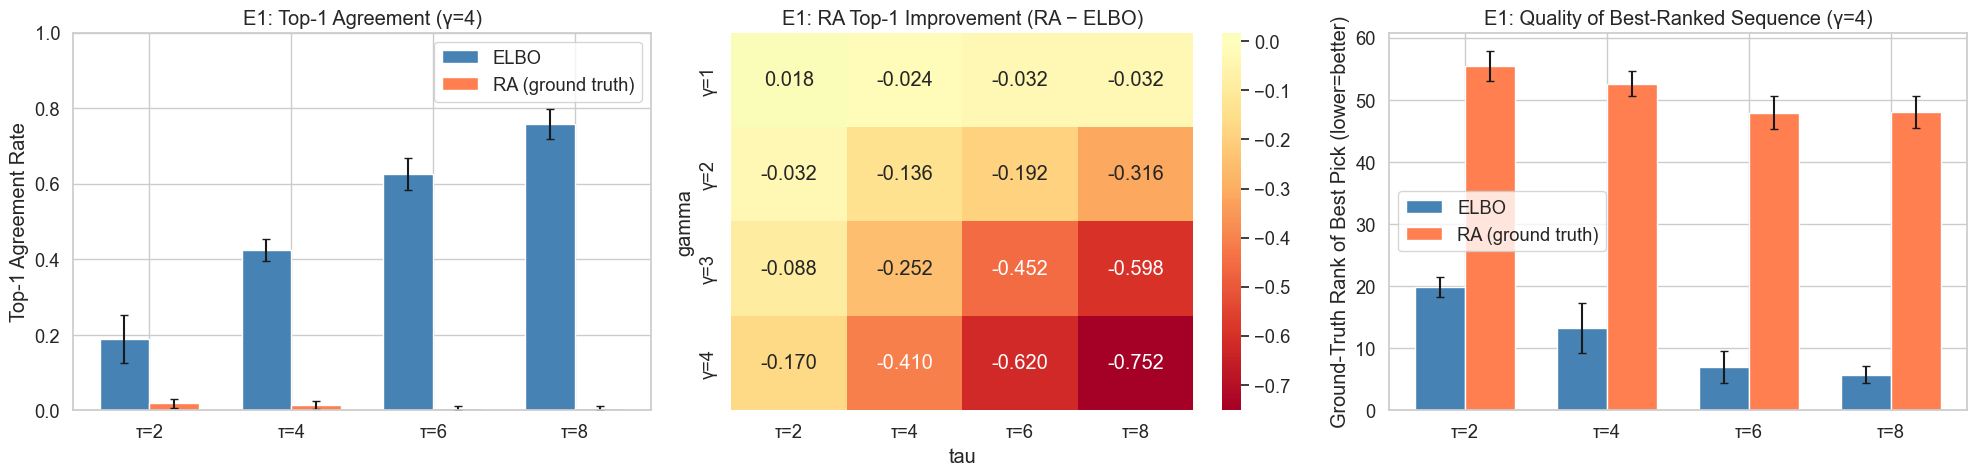

In [7]:
# E1 Visualization: Top-1 agreement comparison — gamma=4 (primary) + all gammas heatmap
import os
FIG_DIR = str(PROJECT_ROOT / 'lightning-hydra-template-main' / 'src' / 'reach_avoid' / 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

if has_ra:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # Panel 1: Top-1 agreement for gamma=4 (decision gate)
    ax = axes[0]
    g4 = per_seed[per_seed.gamma == 4]
    top1_data = g4.groupby('tau')[['elbo_top1', 'ra_top1']].agg(['mean', 'std'])
    x = np.arange(len(TAUS))
    w = 0.35
    ax.bar(x - w/2, [top1_data.loc[t, ('elbo_top1', 'mean')] for t in TAUS],
           yerr=[top1_data.loc[t, ('elbo_top1', 'std')] for t in TAUS],
           width=w, label='ELBO', color='steelblue', capsize=3)
    ax.bar(x + w/2, [top1_data.loc[t, ('ra_top1', 'mean')] for t in TAUS],
           yerr=[top1_data.loc[t, ('ra_top1', 'std')] for t in TAUS],
           width=w, label='RA (ground truth)', color='coral', capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels([f'τ={t}' for t in TAUS])
    ax.set_ylabel('Top-1 Agreement Rate')
    ax.set_title('E1: Top-1 Agreement (γ=4)')
    ax.legend()
    ax.set_ylim(0, 1)
    
    # Panel 2: Heatmap of RA Top-1 improvement (RA - ELBO) across gamma × tau
    ax = axes[1]
    improvement = per_seed.groupby(['gamma', 'tau']).apply(
        lambda x: x['ra_top1'].mean() - x['elbo_top1'].mean()
    ).unstack()
    sns.heatmap(improvement, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
                ax=ax, xticklabels=[f'τ={t}' for t in TAUS],
                yticklabels=[f'γ={g}' for g in GAMMAS])
    ax.set_title('E1: RA Top-1 Improvement (RA − ELBO)')
    
    # Panel 3: Best-pick ground-truth rank for gamma=4
    ax = axes[2]
    rank_data = g4.groupby('tau')[['elbo_best_true_rank', 'ra_best_true_rank']].agg(['mean', 'std'])
    ax.bar(x - w/2, [rank_data.loc[t, ('elbo_best_true_rank', 'mean')] for t in TAUS],
           yerr=[rank_data.loc[t, ('elbo_best_true_rank', 'std')] for t in TAUS],
           width=w, label='ELBO', color='steelblue', capsize=3)
    ax.bar(x + w/2, [rank_data.loc[t, ('ra_best_true_rank', 'mean')] for t in TAUS],
           yerr=[rank_data.loc[t, ('ra_best_true_rank', 'std')] for t in TAUS],
           width=w, label='RA (ground truth)', color='coral', capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels([f'τ={t}' for t in TAUS])
    ax.set_ylabel('Ground-Truth Rank of Best Pick (lower=better)')
    ax.set_title('E1: Quality of Best-Ranked Sequence (γ=4)')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/e1_ranking_comparison.pdf', bbox_inches='tight')
    plt.show()
else:
    print('RA scores not available.')

## E2: Margin Analysis (T2 Theorem Validation)

T2 states that RA ranking is preserved when the margin `m = |P(ā₁) - P(ā₂)| > 2ε_VI + 2τ·ε_soft(κ)`.

We compute pairwise margin distributions under ELBO and RA scoring, and measure the fraction of pairs where the margin is "large enough" to resist ranking inversions.

In [8]:
def compute_pairwise_margins(case_infos, n_pairs_per_individual=500):
    """Compute pairwise margin distributions for ELBO and RA scoring."""
    elbo_margins = []
    ra_margins = []
    elbo_correct = []
    ra_correct = []
    
    rng = np.random.RandomState(42)
    
    for ci in case_infos:
        k = len(ci['model_losses'])
        losses = ci['true_losses']
        elbos = ci['model_losses']
        
        idx_a = rng.randint(0, k, n_pairs_per_individual)
        idx_b = rng.randint(0, k, n_pairs_per_individual)
        mask = idx_a != idx_b
        idx_a, idx_b = idx_a[mask], idx_b[mask]
        
        # Ground truth: a is better if true_loss[a] < true_loss[b]
        gt_sign = np.sign(losses[idx_b] - losses[idx_a])
        
        # ELBO: lower = better, so a is better if elbo[a] < elbo[b]
        elbo_diff = elbos[idx_b] - elbos[idx_a]  # positive if a is better (lower ELBO)
        elbo_margins.extend(np.abs(elbo_diff).tolist())
        elbo_correct.extend((np.sign(elbo_diff) == gt_sign).astype(int).tolist())
        
        if 'ra_scores' in ci:
            ra = ci['ra_scores']
            ra_diff = ra[idx_a] - ra[idx_b]  # positive if a is better (higher RA)
            ra_margins.extend(np.abs(ra_diff).tolist())
            ra_correct.extend((np.sign(ra_diff) == gt_sign).astype(int).tolist())
    
    return {
        'elbo_margins': np.array(elbo_margins),
        'elbo_correct': np.array(elbo_correct),
        'ra_margins': np.array(ra_margins) if ra_margins else None,
        'ra_correct': np.array(ra_correct) if ra_correct else None,
    }

In [9]:
# Compute margins for each gamma × tau
margin_results = {}  # {(gamma, tau): margin_dict}
for gamma in GAMMAS:
    for tau in TAUS:
        # Pool all seeds for this gamma × tau
        all_cis = []
        for seed in all_data[gamma]:
            if tau in all_data[gamma][seed]:
                all_cis.extend(all_data[gamma][seed][tau])
        if not all_cis:
            continue
        margin_results[(gamma, tau)] = compute_pairwise_margins(all_cis)

# Print summary for gamma=4 (primary)
print('=== E2: Pairwise Ranking Accuracy (gamma=4) ===')
for tau in TAUS:
    key = (4, tau)
    if key not in margin_results:
        continue
    em = margin_results[key]['elbo_margins']
    ec = margin_results[key]['elbo_correct']
    print(f'tau={tau}: ELBO accuracy={ec.mean():.3f}, median margin={np.median(em):.4f}')
    
    if margin_results[key]['ra_margins'] is not None:
        rm = margin_results[key]['ra_margins']
        rc = margin_results[key]['ra_correct']
        print(f'        RA accuracy={rc.mean():.3f}, median margin={np.median(rm):.4f}')

# Cross-gamma summary
if has_ra:
    print('\n=== E2: RA vs ELBO Pairwise Accuracy Across Gammas ===')
    for gamma in GAMMAS:
        for tau in TAUS:
            key = (gamma, tau)
            if key not in margin_results or margin_results[key]['ra_margins'] is None:
                continue
            ec = margin_results[key]['elbo_correct'].mean()
            rc = margin_results[key]['ra_correct'].mean()
            print(f'  gamma={gamma}, tau={tau}: ELBO={ec:.3f}, RA={rc:.3f}, Δ={rc-ec:+.3f}')

=== E2: Pairwise Ranking Accuracy (gamma=4) ===
tau=2: ELBO accuracy=0.783, median margin=6.6777
        RA accuracy=0.122, median margin=0.0000
tau=4: ELBO accuracy=0.832, median margin=8.0784
        RA accuracy=0.291, median margin=0.0000
tau=6: ELBO accuracy=0.855, median margin=9.9008
        RA accuracy=0.429, median margin=0.0000
tau=8: ELBO accuracy=0.863, median margin=11.5836
        RA accuracy=0.511, median margin=0.0000

=== E2: RA vs ELBO Pairwise Accuracy Across Gammas ===
  gamma=1, tau=2: ELBO=0.590, RA=0.215, Δ=-0.375
  gamma=1, tau=4: ELBO=0.629, RA=0.353, Δ=-0.275
  gamma=1, tau=6: ELBO=0.654, RA=0.442, Δ=-0.212
  gamma=1, tau=8: ELBO=0.689, RA=0.505, Δ=-0.184
  gamma=2, tau=2: ELBO=0.703, RA=0.188, Δ=-0.514
  gamma=2, tau=4: ELBO=0.750, RA=0.344, Δ=-0.406
  gamma=2, tau=6: ELBO=0.786, RA=0.454, Δ=-0.331
  gamma=2, tau=8: ELBO=0.806, RA=0.529, Δ=-0.277
  gamma=3, tau=2: ELBO=0.765, RA=0.152, Δ=-0.613
  gamma=3, tau=4: ELBO=0.804, RA=0.316, Δ=-0.488
  gamma=3, tau=6:

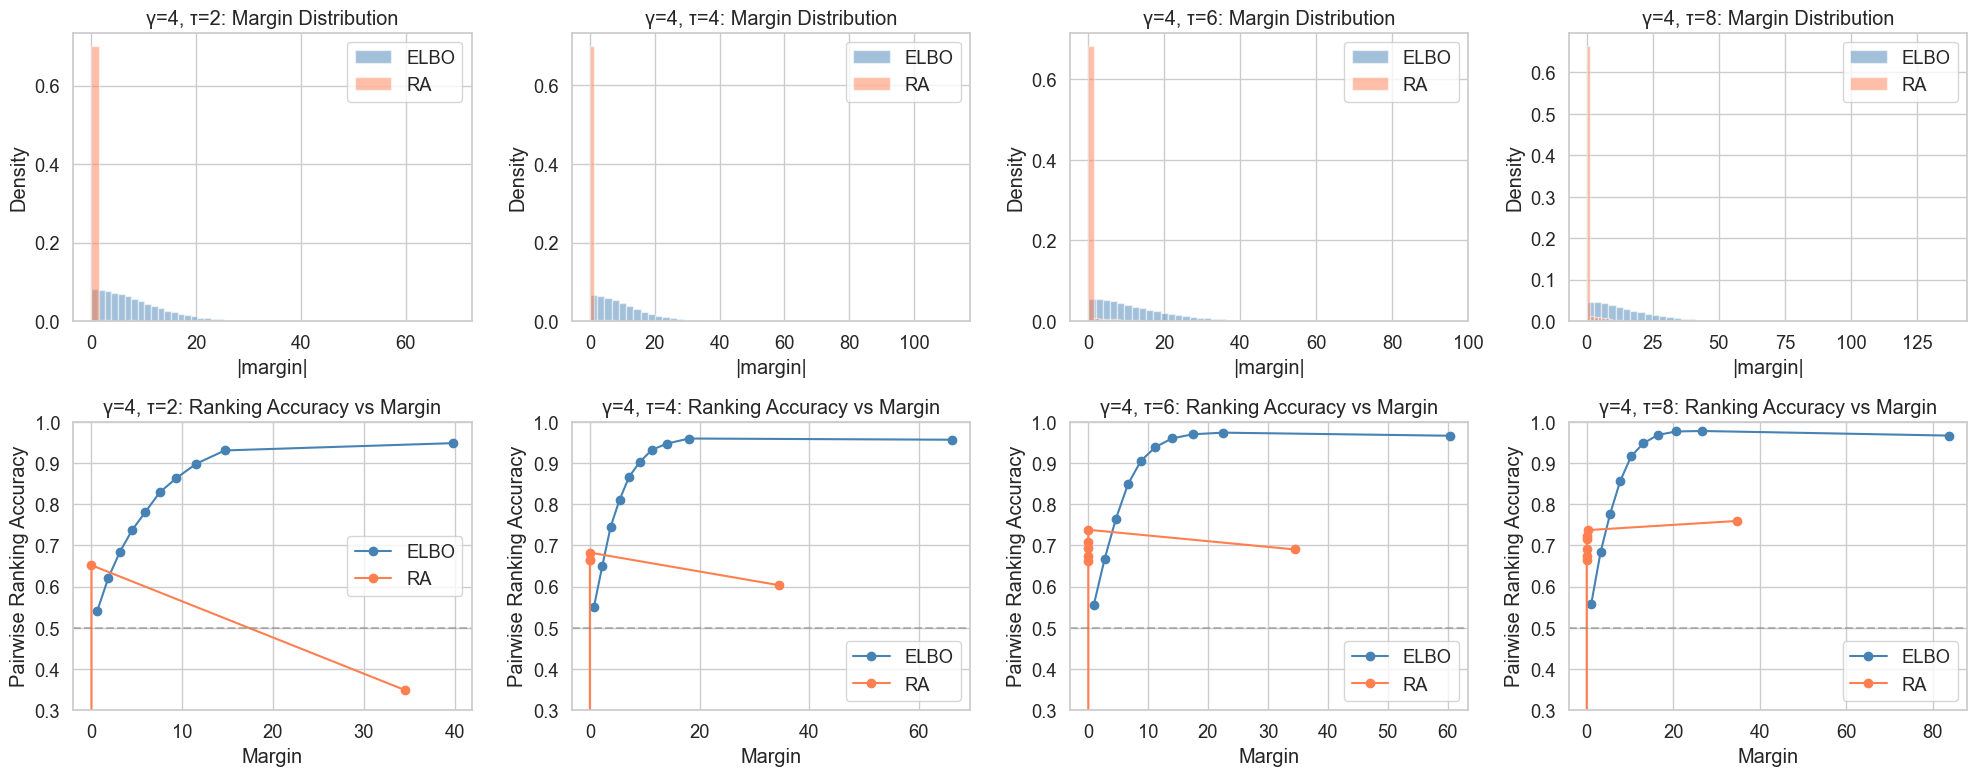

In [10]:
# E2 Visualization: Margin distributions and accuracy vs margin (gamma=4)
if has_ra:
    fig, axes = plt.subplots(2, len(TAUS), figsize=(5*len(TAUS), 8))
    
    for j, tau in enumerate(TAUS):
        key = (4, tau)
        if key not in margin_results:
            continue
        mr = margin_results[key]
        
        ax = axes[0, j]
        ax.hist(mr['elbo_margins'], bins=50, alpha=0.5, label='ELBO', color='steelblue', density=True)
        if mr['ra_margins'] is not None:
            ax.hist(mr['ra_margins'], bins=50, alpha=0.5, label='RA', color='coral', density=True)
        ax.set_title(f'γ=4, τ={tau}: Margin Distribution')
        ax.set_xlabel('|margin|')
        ax.set_ylabel('Density')
        ax.legend()
        
        ax = axes[1, j]
        items = [('ELBO', mr['elbo_margins'], mr['elbo_correct'], 'steelblue')]
        if mr['ra_margins'] is not None:
            items.append(('RA', mr['ra_margins'], mr['ra_correct'], 'coral'))
        
        for name, margins, correct, color in items:
            percentiles = np.percentile(margins, np.linspace(0, 100, 11))
            bin_centers = []
            bin_accs = []
            for i in range(len(percentiles)-1):
                mask = (margins >= percentiles[i]) & (margins < percentiles[i+1])
                if mask.sum() > 0:
                    bin_centers.append((percentiles[i] + percentiles[i+1]) / 2)
                    bin_accs.append(correct[mask].mean())
            ax.plot(bin_centers, bin_accs, 'o-', label=name, color=color)
        ax.axhline(0.5, ls='--', color='gray', alpha=0.5)
        ax.set_title(f'γ=4, τ={tau}: Ranking Accuracy vs Margin')
        ax.set_xlabel('Margin')
        ax.set_ylabel('Pairwise Ranking Accuracy')
        ax.legend()
        ax.set_ylim(0.3, 1.0)
    
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/e2_margin_analysis.pdf', bbox_inches='tight')
    plt.show()

In [11]:
# E2 Key metric: fraction of pairs where ranking is preserved at various margin thresholds
# This directly validates T2: larger margins → more robust rankings
if has_ra:
    print('=== E2: Pairwise Ranking Accuracy by Margin Percentile (gamma=4) ===')
    print()
    for tau in TAUS:
        key = (4, tau)
        if key not in margin_results or margin_results[key]['ra_margins'] is None:
            continue
        mr = margin_results[key]
        print(f'tau={tau}:')
        for pct in [25, 50, 75, 90]:
            elbo_thresh = np.percentile(mr['elbo_margins'], pct)
            ra_thresh = np.percentile(mr['ra_margins'], pct)
            
            elbo_mask = mr['elbo_margins'] >= elbo_thresh
            ra_mask = mr['ra_margins'] >= ra_thresh
            
            elbo_acc = mr['elbo_correct'][elbo_mask].mean()
            ra_acc = mr['ra_correct'][ra_mask].mean()
            
            print(f'  Top {100-pct}% margin: ELBO acc={elbo_acc:.3f}, RA acc={ra_acc:.3f}')
        print()
    
    # Cross-gamma: show the fraction of pairs where RA margin exceeds ELBO margin
    print('=== E2: Fraction of Pairs with RA Margin > ELBO Margin ===')
    for gamma in GAMMAS:
        for tau in TAUS:
            key = (gamma, tau)
            if key not in margin_results or margin_results[key]['ra_margins'] is None:
                continue
            mr = margin_results[key]
            # Compare at same percentile thresholds
            ra_median = np.median(mr['ra_margins'])
            elbo_median = np.median(mr['elbo_margins'])
            print(f'  gamma={gamma}, tau={tau}: RA median={ra_median:.4f}, ELBO median={elbo_median:.4f}')

=== E2: Pairwise Ranking Accuracy by Margin Percentile (gamma=4) ===

tau=2:
  Top 75% margin: ELBO acc=0.845, RA acc=0.122
  Top 50% margin: ELBO acc=0.894, RA acc=0.122
  Top 25% margin: ELBO acc=0.933, RA acc=0.122
  Top 10% margin: ELBO acc=0.948, RA acc=0.349

tau=4:
  Top 75% margin: ELBO acc=0.901, RA acc=0.291
  Top 50% margin: ELBO acc=0.939, RA acc=0.291
  Top 25% margin: ELBO acc=0.957, RA acc=0.648
  Top 10% margin: ELBO acc=0.956, RA acc=0.604

tau=6:
  Top 75% margin: ELBO acc=0.927, RA acc=0.429
  Top 50% margin: ELBO acc=0.961, RA acc=0.701
  Top 25% margin: ELBO acc=0.970, RA acc=0.713
  Top 10% margin: ELBO acc=0.966, RA acc=0.690

tau=8:
  Top 75% margin: ELBO acc=0.934, RA acc=0.511
  Top 50% margin: ELBO acc=0.967, RA acc=0.725
  Top 25% margin: ELBO acc=0.973, RA acc=0.745
  Top 10% margin: ELBO acc=0.966, RA acc=0.759

=== E2: Fraction of Pairs with RA Margin > ELBO Margin ===
  gamma=1, tau=2: RA median=0.0000, ELBO median=0.7941
  gamma=1, tau=4: RA median=0.00

  gamma=4, tau=4: RA median=0.0000, ELBO median=8.0784
  gamma=4, tau=6: RA median=0.0000, ELBO median=9.9008
  gamma=4, tau=8: RA median=0.0000, ELBO median=11.5836


## E3: Cross-Seed Ranking Stability (Cancer)

For each individual × gamma × tau, compare how stable the rankings are across seeds.
More stable rankings → more reliable clinical recommendations.

Note: MIMIC stability analysis deferred to Phase 1B.

In [12]:
# Cross-seed stability: for each individual, compute rank std across seeds
stability_results = []

for gamma in GAMMAS:
    for tau in TAUS:
        individual_elbo_ranks = {}
        individual_ra_ranks = {}
        
        for seed in all_data[gamma]:
            if tau not in all_data[gamma][seed]:
                continue
            for ci in all_data[gamma][seed][tau]:
                iid = ci['individual_id']
                
                if iid not in individual_elbo_ranks:
                    individual_elbo_ranks[iid] = []
                    individual_ra_ranks[iid] = []
                
                individual_elbo_ranks[iid].append(ci['true_sequence_rank'])
                
                if has_ra and 'ra_scores' in ci:
                    # Compute RA rank of true sequence (last in all_sequences)
                    ra = ci['ra_scores']
                    ra_rank = int(np.sum(ra > ra[-1]) + 1)
                    individual_ra_ranks[iid].append(ra_rank)
        
        for iid in individual_elbo_ranks:
            if len(individual_elbo_ranks[iid]) < 2:
                continue
            elbo_std = np.std(individual_elbo_ranks[iid])
            row = {'gamma': gamma, 'tau': tau, 'individual_id': iid, 'elbo_rank_std': elbo_std}
            
            if has_ra and individual_ra_ranks.get(iid) and len(individual_ra_ranks[iid]) >= 2:
                row['ra_rank_std'] = np.std(individual_ra_ranks[iid])
            
            stability_results.append(row)

df_stab = pd.DataFrame(stability_results)

print('=== E3: Cross-Seed Ranking Stability (rank std, lower=more stable) ===')
print()
for gamma in GAMMAS:
    sub = df_stab[df_stab.gamma == gamma]
    if sub.empty:
        continue
    print(f'--- gamma={gamma} ---')
    stab_cols = ['elbo_rank_std']
    if has_ra and 'ra_rank_std' in sub.columns:
        stab_cols.append('ra_rank_std')
    stab_summary = sub.groupby('tau')[stab_cols].agg(['mean', 'median'])
    print(stab_summary)
    print()

=== E3: Cross-Seed Ranking Stability (rank std, lower=more stable) ===

--- gamma=1 ---
    elbo_rank_std            ra_rank_std           
             mean     median        mean     median
tau                                                
2       21.017133  21.304085   10.781112   0.000000
4       19.866555  19.665198   18.444114  23.800000
6       17.582361  17.725416   17.534614  21.710545
8       15.629764  14.785076   20.976697  24.434094

--- gamma=2 ---
    elbo_rank_std            ra_rank_std       
             mean     median        mean median
tau                                            
2       15.084882  15.448696    7.542035    0.0
4       10.596432   9.294633    8.942786    0.0
6        7.433539   5.966389   11.278596    0.0
8        5.023842   3.504241   10.901520    0.0

--- gamma=3 ---
    elbo_rank_std            ra_rank_std       
             mean     median        mean median
tau                                            
2       11.596659  11.045169    8.

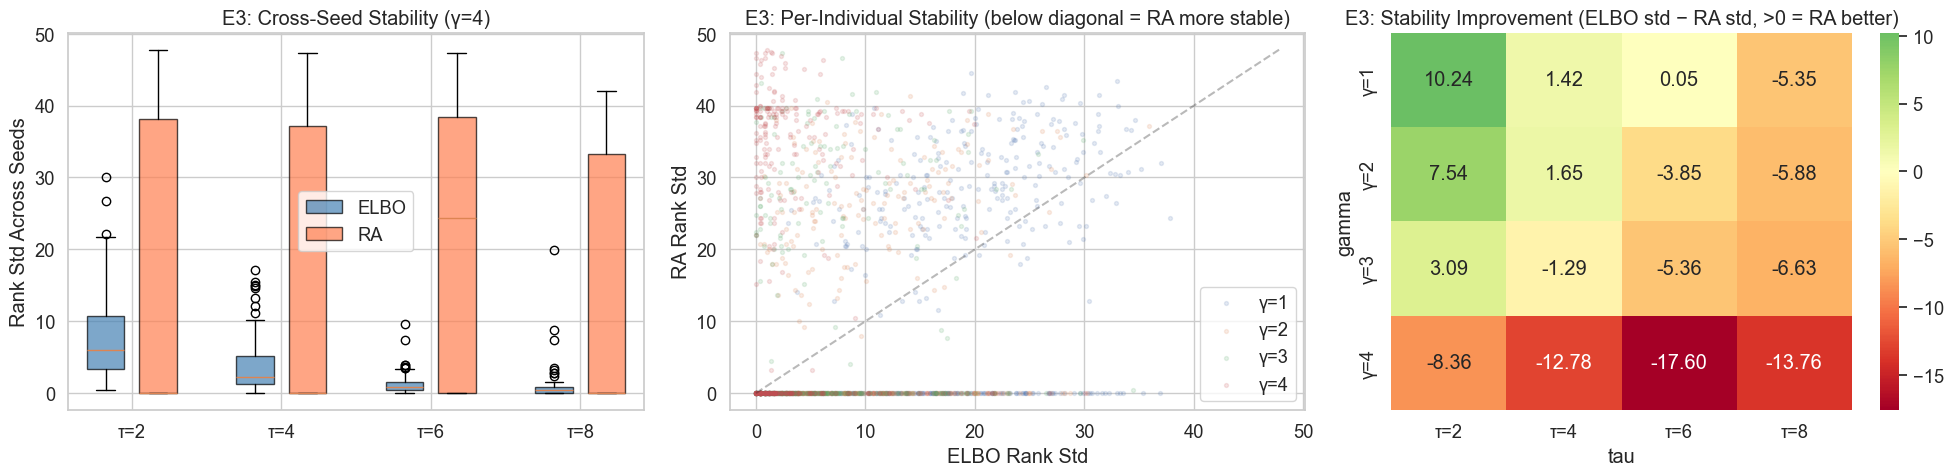

In [13]:
# E3 Visualization: stability comparison
if has_ra and 'ra_rank_std' in df_stab.columns:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    ax = axes[0]
    g4_stab = df_stab[df_stab.gamma == 4]
    positions_elbo = np.arange(len(TAUS)) * 2
    positions_ra = positions_elbo + 0.7
    
    bp1 = ax.boxplot([g4_stab[g4_stab.tau==t]['elbo_rank_std'].dropna().values for t in TAUS],
                     positions=positions_elbo, widths=0.5, patch_artist=True)
    bp2 = ax.boxplot([g4_stab[g4_stab.tau==t]['ra_rank_std'].dropna().values for t in TAUS],
                     positions=positions_ra, widths=0.5, patch_artist=True)
    
    for patch in bp1['boxes']:
        patch.set_facecolor('steelblue'); patch.set_alpha(0.7)
    for patch in bp2['boxes']:
        patch.set_facecolor('coral'); patch.set_alpha(0.7)
    
    ax.set_xticks(positions_elbo + 0.35)
    ax.set_xticklabels([f'τ={t}' for t in TAUS])
    ax.set_ylabel('Rank Std Across Seeds')
    ax.set_title('E3: Cross-Seed Stability (γ=4)')
    ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['ELBO', 'RA'])
    
    ax = axes[1]
    for gamma in GAMMAS:
        sub = df_stab[df_stab.gamma == gamma].dropna(subset=['ra_rank_std'])
        ax.scatter(sub['elbo_rank_std'], sub['ra_rank_std'], alpha=0.15, s=8, label=f'γ={gamma}')
    max_val = max(df_stab['elbo_rank_std'].max(), df_stab['ra_rank_std'].dropna().max())
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3)
    ax.set_xlabel('ELBO Rank Std'); ax.set_ylabel('RA Rank Std')
    ax.set_title('E3: Per-Individual Stability (below diagonal = RA more stable)')
    ax.legend()
    
    ax = axes[2]
    stab_improvement = df_stab.dropna(subset=['ra_rank_std']).groupby(['gamma', 'tau']).apply(
        lambda x: x['elbo_rank_std'].mean() - x['ra_rank_std'].mean()
    ).unstack()
    sns.heatmap(stab_improvement, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
                ax=ax, xticklabels=[f'τ={t}' for t in TAUS],
                yticklabels=[f'γ={g}' for g in GAMMAS])
    ax.set_title('E3: Stability Improvement (ELBO std − RA std, >0 = RA better)')
    
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/e3_ranking_stability.pdf', bbox_inches='tight')
    plt.show()

## Decision Gate Summary

Evaluate whether to proceed with Phase 2 based on Phase 1 results.

In [14]:
print('=' * 70)
print('PHASE 1A DECISION GATE SUMMARY')
print('=' * 70)
print()

if has_ra:
    # Primary decision: gamma=4 (strongest confounding, most challenging)
    print('--- Primary (gamma=4) ---')
    g4_seed = per_seed[per_seed.gamma == 4]
    for tau in TAUS:
        sub = g4_seed[g4_seed.tau == tau]
        if sub.empty:
            continue
        elbo_t1 = sub['elbo_top1'].mean()
        ra_t1 = sub['ra_top1'].mean()
        improvement = ra_t1 - elbo_t1
        
        stab_sub = df_stab[(df_stab.gamma == 4) & (df_stab.tau == tau)]
        elbo_stab = stab_sub['elbo_rank_std'].mean()
        ra_stab = stab_sub['ra_rank_std'].mean() if 'ra_rank_std' in stab_sub.columns else float('nan')
        
        status = 'PASS' if improvement > 0.05 else ('MARGINAL' if improvement > 0 else 'FAIL')
        print(f'  tau={tau}: ELBO Top-1={elbo_t1:.3f} → RA Top-1={ra_t1:.3f} '
              f'(Δ={improvement:+.3f}) [{status}]')
        print(f'           Stability: ELBO std={elbo_stab:.1f} → RA std={ra_stab:.1f}')
    
    # Cross-gamma summary
    print()
    print('--- Cross-Gamma Summary ---')
    for gamma in GAMMAS:
        sub = per_seed[per_seed.gamma == gamma]
        if sub.empty:
            continue
        elbo_t1 = sub['elbo_top1'].mean()
        ra_t1 = sub['ra_top1'].mean()
        print(f'  gamma={gamma}: ELBO Top-1={elbo_t1:.3f}, RA Top-1={ra_t1:.3f}, Δ={ra_t1-elbo_t1:+.3f}')
    
    # Overall
    print()
    overall_elbo = per_seed['elbo_top1'].mean()
    overall_ra = per_seed['ra_top1'].mean()
    print(f'Overall: ELBO Top-1={overall_elbo:.3f}, RA Top-1={overall_ra:.3f}, Δ={overall_ra-overall_elbo:+.3f}')
    print()
    
    # Decision
    g4_elbo = g4_seed['elbo_top1'].mean()
    g4_ra = g4_seed['ra_top1'].mean()
    
    if g4_ra > g4_elbo + 0.05:
        print('DECISION: PROCEED to Phase 1B (MIMIC) and Phase 2 (RA-aware retraining).')
        print('RA scoring shows substantial improvement on Cancer ground truth.')
    elif g4_ra > g4_elbo:
        print('DECISION: PROCEED with CAUTION to Phase 1B.')
        print('RA shows modest improvement. Investigate whether stability or margin gains')
        print('justify the additional complexity before committing to Phase 2.')
    else:
        print('DECISION: REASSESS approach.')
        print('RA scoring does not improve over ELBO on Cancer ground truth.')
        print('Consider: (1) tuning T/S thresholds, (2) alternative target definitions,')
        print('(3) pivoting to a different contribution.')
else:
    print('RA scores not available. Run scripts/phase1/run_phase1.sh on Vast.ai first.')
    print()
    print('Current ELBO-only baseline metrics (gamma=4):')
    g4_seed = per_seed[per_seed.gamma == 4]
    for tau in TAUS:
        sub = g4_seed[g4_seed.tau == tau]
        if not sub.empty:
            print(f'  tau={tau}: ELBO Top-1={sub["elbo_top1"].mean():.3f} ± {sub["elbo_top1"].std():.3f}')

PHASE 1A DECISION GATE SUMMARY

--- Primary (gamma=4) ---
  tau=2: ELBO Top-1=0.188 → RA Top-1=0.018 (Δ=-0.170) [FAIL]
           Stability: ELBO std=7.8 → RA std=16.2
  tau=4: ELBO Top-1=0.424 → RA Top-1=0.014 (Δ=-0.410) [FAIL]
           Stability: ELBO std=3.6 → RA std=16.4
  tau=6: ELBO Top-1=0.626 → RA Top-1=0.006 (Δ=-0.620) [FAIL]
           Stability: ELBO std=1.3 → RA std=18.9
  tau=8: ELBO Top-1=0.758 → RA Top-1=0.006 (Δ=-0.752) [FAIL]
           Stability: ELBO std=1.0 → RA std=14.8

--- Cross-Gamma Summary ---
  gamma=1: ELBO Top-1=0.053, RA Top-1=0.035, Δ=-0.017
  gamma=2: ELBO Top-1=0.188, RA Top-1=0.019, Δ=-0.169
  gamma=3: ELBO Top-1=0.364, RA Top-1=0.017, Δ=-0.347
  gamma=4: ELBO Top-1=0.499, RA Top-1=0.011, Δ=-0.488

Overall: ELBO Top-1=0.276, RA Top-1=0.020, Δ=-0.256

DECISION: REASSESS approach.
RA scoring does not improve over ELBO on Cancer ground truth.
Consider: (1) tuning T/S thresholds, (2) alternative target definitions,
(3) pivoting to a different contributio

## E4: RA-Constrained ELBO Selection (Option 2)

**Key insight from Phase 1A:** RA alone cannot rank sequences (near-chance Top-1), but ELBO ranks well. The natural combination: use RA as a **feasibility filter** and ELBO as the **ranking criterion**.

**Method:** `ā* = argmin_{ā ∈ F_RA} ELBO(ā)` where `F_RA = {ā : RA_feasible(ā)}`

A sequence is RA-feasible if its trajectory features satisfy:
- `cv_terminal ≤ target_upper` (tumor control at horizon)
- `cv_max ≤ safety_volume_upper` (tumor safety throughout)
- `cd_max ≤ safety_chemo_upper` (chemo toxicity limit)

We use hard thresholds (not soft indicators) for the filter, then sweep across threshold configurations to measure:
1. **Constrained Top-1**: does the best ELBO sequence *among feasible ones* match ground-truth best?
2. **Safety rate**: fraction of selected sequences that are clinically safe
3. **Feasibility rate**: what fraction of candidate sequences pass the filter?
4. **Ground-truth quality**: average true_loss of the selected sequence

In [15]:
def evaluate_constrained_selection(case_infos, target_upper, safety_vol_upper=None,
                                    safety_chemo_upper=None):
    """Evaluate RA-constrained ELBO selection for a list of case_infos.
    
    For each individual:
    1. Compute feasibility mask from trajectory features (hard thresholds)
    2. Among feasible sequences, select the one with best (lowest) ELBO
    3. Compare to unconstrained ELBO selection and ground-truth best
    
    Returns dict of metrics.
    """
    results = []
    for ci in case_infos:
        if 'traj_features' not in ci:
            continue
        tf = ci['traj_features']
        elbos = ci['model_losses']
        true_losses = ci['true_losses']
        k = len(elbos)
        
        # Ground truth best
        best_true_idx = np.argmin(true_losses)
        best_true_loss = true_losses[best_true_idx]
        
        # Unconstrained ELBO best
        best_elbo_idx = np.argmin(elbos)
        elbo_selected_loss = true_losses[best_elbo_idx]
        elbo_top1 = int(best_elbo_idx == best_true_idx)
        
        # Feasibility mask (hard thresholds)
        feasible = np.ones(k, dtype=bool)
        feasible &= tf['cv_terminal'] <= target_upper
        if safety_vol_upper is not None:
            feasible &= tf['cv_max'] <= safety_vol_upper
        if safety_chemo_upper is not None:
            feasible &= tf['cd_max'] <= safety_chemo_upper
        
        n_feasible = feasible.sum()
        feas_rate = n_feasible / k
        
        # Is ground-truth best feasible?
        gt_feasible = feasible[best_true_idx]
        
        # Safety of unconstrained ELBO pick
        elbo_pick_feasible = feasible[best_elbo_idx]
        
        if n_feasible > 0:
            # Constrained selection: best ELBO among feasible
            feasible_elbos = np.where(feasible, elbos, np.inf)
            constrained_idx = np.argmin(feasible_elbos)
            constrained_loss = true_losses[constrained_idx]
            constrained_top1 = int(constrained_idx == best_true_idx)
            constrained_feasible = True  # by construction
        else:
            # No feasible sequences — fall back to unconstrained ELBO
            constrained_idx = best_elbo_idx
            constrained_loss = elbo_selected_loss
            constrained_top1 = elbo_top1
            constrained_feasible = False
        
        # Safety metrics for selected sequence
        results.append({
            'individual_id': ci['individual_id'],
            # Ranking
            'elbo_top1': elbo_top1,
            'constrained_top1': constrained_top1,
            # Quality (lower = better)
            'best_true_loss': best_true_loss,
            'elbo_selected_loss': elbo_selected_loss,
            'constrained_selected_loss': constrained_loss,
            # Safety
            'elbo_pick_feasible': int(elbo_pick_feasible),
            'constrained_pick_feasible': int(constrained_feasible),
            'gt_feasible': int(gt_feasible),
            # Feasibility
            'feasibility_rate': feas_rate,
            'n_feasible': n_feasible,
            # Trajectory features of selected sequences
            'elbo_cv_terminal': tf['cv_terminal'][best_elbo_idx],
            'constrained_cv_terminal': tf['cv_terminal'][constrained_idx],
            'elbo_cd_max': tf['cd_max'][best_elbo_idx],
            'constrained_cd_max': tf['cd_max'][constrained_idx],
        })
    return results

In [16]:
# E4 Threshold sweep for constrained selection
# Key question: what thresholds give the best trade-off between
# safety (higher constraint rate) and quality (lower true_loss)?

# Use percentile-based thresholds from the trajectory feature distributions
# (computed earlier: cv_terminal p50≈0.13, p75≈0.59, p95≈3.17 for gamma=4)

e4_configs = [
    # (name, target_upper, safety_vol, safety_chemo)
    ('Loose: target only p95',    3.0,  None, None),
    ('Loose: target only p75',    0.6,  None, None),
    ('Moderate: target p75 + vol', 0.6, 5.0, None),
    ('Moderate: target p75 + chemo', 0.6, None, 8.5),
    ('Moderate: all three',       0.6,  5.0,  8.5),
    ('Strict: target p50',        0.15, None, None),
    ('Strict: target p50 + vol',  0.15, 2.0,  None),
    ('Strict: target p50 + all',  0.15, 2.0,  8.0),
    ('Very strict: all',          0.05, 1.0,  7.5),
]

print('=== E4: Constrained Selection Sweep (gamma=4, all taus pooled) ===')
print(f'{"Config":<30} {"Feas%":>6} {"ELBO T1":>8} {"Cstr T1":>8} {"ΔT1":>6} '
      f'{"ELBO safe%":>10} {"Cstr safe%":>10} {"ELBO loss":>10} {"Cstr loss":>10}')
print('-' * 120)

e4_sweep = []
for name, target, sv, sc in e4_configs:
    all_results = []
    for seed in all_data[4]:
        for tau in TAUS:
            if tau not in all_data[4][seed]:
                continue
            all_results.extend(
                evaluate_constrained_selection(all_data[4][seed][tau], target, sv, sc))
    
    df_e4 = pd.DataFrame(all_results)
    feas = df_e4['feasibility_rate'].mean()
    elbo_t1 = df_e4['elbo_top1'].mean()
    cstr_t1 = df_e4['constrained_top1'].mean()
    elbo_safe = df_e4['elbo_pick_feasible'].mean()
    cstr_safe = df_e4['constrained_pick_feasible'].mean()
    elbo_loss = df_e4['elbo_selected_loss'].mean()
    cstr_loss = df_e4['constrained_selected_loss'].mean()
    
    print(f'{name:<30} {feas:6.1%} {elbo_t1:8.3f} {cstr_t1:8.3f} {cstr_t1-elbo_t1:+6.3f} '
          f'{elbo_safe:10.1%} {cstr_safe:10.1%} {elbo_loss:10.6f} {cstr_loss:10.6f}')
    
    e4_sweep.append({
        'name': name, 'target': target, 'safety_vol': sv, 'safety_chemo': sc,
        'feas_rate': feas, 'elbo_top1': elbo_t1, 'constrained_top1': cstr_t1,
        'delta_top1': cstr_t1 - elbo_t1,
        'elbo_safe': elbo_safe, 'constrained_safe': cstr_safe,
        'elbo_loss': elbo_loss, 'constrained_loss': cstr_loss,
    })

df_e4_sweep = pd.DataFrame(e4_sweep)

=== E4: Constrained Selection Sweep (gamma=4, all taus pooled) ===
Config                          Feas%  ELBO T1  Cstr T1    ΔT1 ELBO safe% Cstr safe%  ELBO loss  Cstr loss
------------------------------------------------------------------------------------------------------------------------
Loose: target only p95          94.6%    0.499    0.440 -0.059      85.0%      98.2%   0.003520   0.007823
Loose: target only p75          75.3%    0.499    0.309 -0.190      52.9%      88.7%   0.003520   0.011728
Moderate: target p75 + vol      74.7%    0.499    0.317 -0.182      52.9%      86.7%   0.003520   0.010156
Moderate: target p75 + chemo    69.6%    0.499    0.314 -0.185      52.9%      87.8%   0.003520   0.011288
Moderate: all three             69.1%    0.499    0.320 -0.179      52.9%      86.0%   0.003520   0.009874
Strict: target p50              52.3%    0.499    0.246 -0.253      29.2%      74.1%   0.003520   0.010185
Strict: target p50 + vol        51.0%    0.499    0.281 -0.218 

In [17]:
# E4 Detailed analysis: best config per gamma × tau breakdown
# Pick a representative "moderate" config for detailed analysis
FILTER_TARGET = 0.6
FILTER_VOL = 5.0
FILTER_CHEMO = 8.5

print(f'=== E4 Detailed: Constrained Selection (target≤{FILTER_TARGET}, vol≤{FILTER_VOL}, chemo≤{FILTER_CHEMO}) ===')
print(f'{"Gamma":>6} {"Tau":>4} | {"Feas%":>6} {"ELBO T1":>8} {"Cstr T1":>8} {"ΔT1":>6} | '
      f'{"ELBO safe%":>10} {"Cstr safe%":>10} | {"ELBO loss":>10} {"Cstr loss":>10} {"ΔLoss":>8}')
print('-' * 110)

e4_detailed = []
for gamma in GAMMAS:
    for tau in TAUS:
        all_results = []
        for seed in all_data[gamma]:
            if tau not in all_data[gamma][seed]:
                continue
            all_results.extend(
                evaluate_constrained_selection(
                    all_data[gamma][seed][tau], FILTER_TARGET, FILTER_VOL, FILTER_CHEMO))
        
        if not all_results:
            continue
        
        df_detail = pd.DataFrame(all_results)
        feas = df_detail['feasibility_rate'].mean()
        e_t1 = df_detail['elbo_top1'].mean()
        c_t1 = df_detail['constrained_top1'].mean()
        e_safe = df_detail['elbo_pick_feasible'].mean()
        c_safe = df_detail['constrained_pick_feasible'].mean()
        e_loss = df_detail['elbo_selected_loss'].mean()
        c_loss = df_detail['constrained_selected_loss'].mean()
        
        print(f'{gamma:6} {tau:4} | {feas:6.1%} {e_t1:8.3f} {c_t1:8.3f} {c_t1-e_t1:+6.3f} | '
              f'{e_safe:10.1%} {c_safe:10.1%} | {e_loss:10.6f} {c_loss:10.6f} {c_loss-e_loss:+8.6f}')
        
        e4_detailed.append({
            'gamma': gamma, 'tau': tau,
            'feas_rate': feas, 'elbo_top1': e_t1, 'constrained_top1': c_t1,
            'delta_top1': c_t1 - e_t1,
            'elbo_safe': e_safe, 'constrained_safe': c_safe,
            'elbo_loss': e_loss, 'constrained_loss': c_loss,
            'delta_loss': c_loss - e_loss,
        })

df_e4_detail = pd.DataFrame(e4_detailed)

# Summary
print()
print('=== Cross-Gamma Summary ===')
for gamma in GAMMAS:
    sub = df_e4_detail[df_e4_detail.gamma == gamma]
    if sub.empty:
        continue
    print(f'  gamma={gamma}: avg ΔTop1={sub["delta_top1"].mean():+.3f}, '
          f'avg safety improvement={sub["constrained_safe"].mean()-sub["elbo_safe"].mean():+.1%}, '
          f'avg feasibility={sub["feas_rate"].mean():.1%}')

=== E4 Detailed: Constrained Selection (target≤0.6, vol≤5.0, chemo≤8.5) ===
 Gamma  Tau |  Feas%  ELBO T1  Cstr T1    ΔT1 | ELBO safe% Cstr safe% |  ELBO loss  Cstr loss    ΔLoss
--------------------------------------------------------------------------------------------------------------
     1    2 |  93.8%    0.028    0.028 +0.000 |      95.6%      98.2% |   0.000384   0.000374 -0.000009
     1    4 |  89.7%    0.056    0.056 +0.000 |      95.6%      98.0% |   0.000685   0.000655 -0.000031


     1    6 |  85.1%    0.058    0.060 +0.002 |      94.8%      98.8% |   0.000959   0.000854 -0.000105
     1    8 |  80.7%    0.068    0.068 +0.000 |      96.0%      99.2% |   0.000684   0.000550 -0.000134


     2    2 |  87.1%    0.056    0.052 -0.004 |      85.8%      93.0% |   0.001281   0.001431 +0.000150
     2    4 |  85.8%    0.152    0.146 -0.006 |      86.0%      94.0% |   0.001910   0.002007 +0.000098
     2    6 |  82.7%    0.218    0.204 -0.014 |      87.4%      95.4% |   0.001795   0.001981 +0.000186
     2    8 |  79.5%    0.326    0.302 -0.024 |      88.4%      96.4% |   0.001036   0.001540 +0.000504
     3    2 |  80.2%    0.112    0.110 -0.002 |      74.4%      88.0% |   0.002004   0.002985 +0.000981
     3    4 |  80.1%    0.272    0.214 -0.058 |      71.4%      92.6% |   0.002874   0.004982 +0.002108
     3    6 |  79.1%    0.470    0.386 -0.084 |      74.2%      94.0% |   0.002270   0.004656 +0.002386
     3    8 |  77.8%    0.602    0.494 -0.108 |      76.8%      95.4% |   0.001090   0.004142 +0.003053
     4    2 |  63.8%    0.188    0.122 -0.066 |      51.6%      78.8% |   0.003499   0.006867 +0.003369
     4    4 |  69.2%    0.424    0.286 -0.138 |      52.2%      

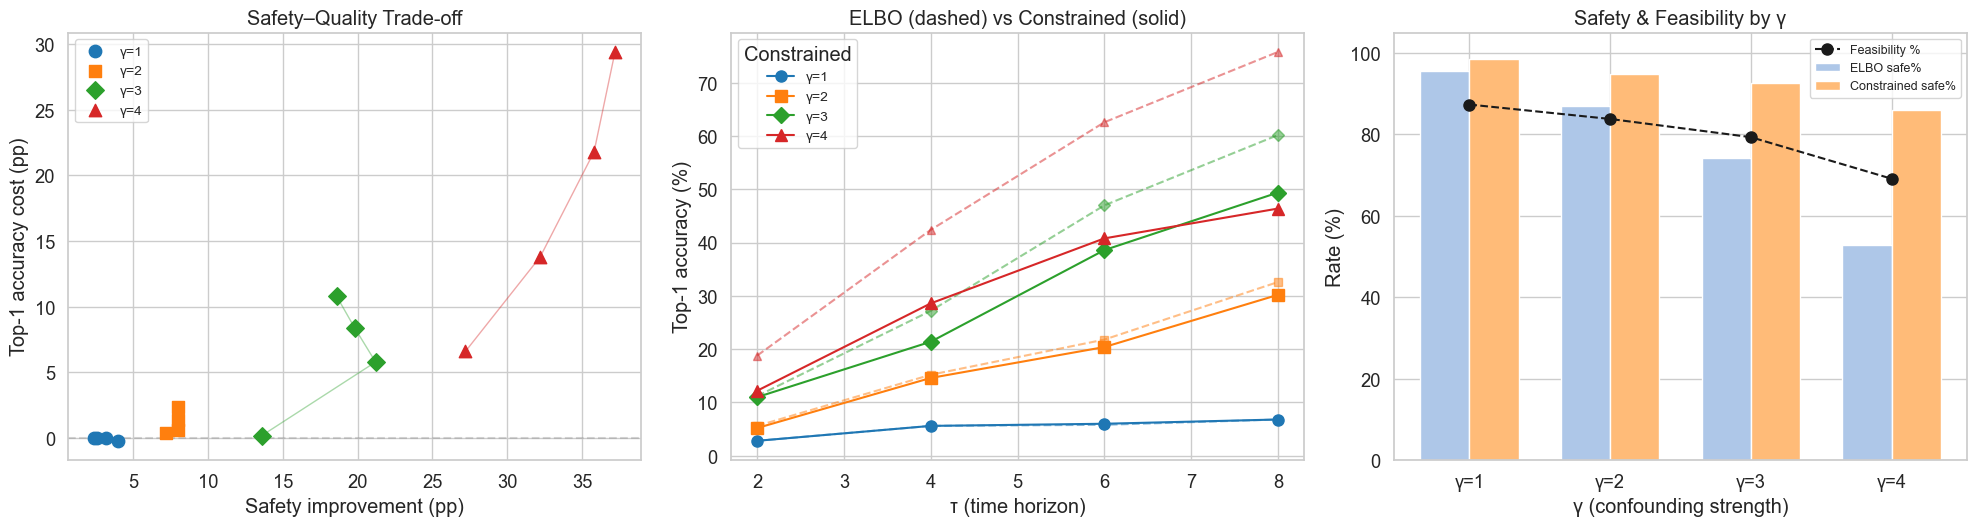

Saved: /Users/anisiomlacerda/code/target-counterfactual/lightning-hydra-template-main/src/reach_avoid/figures/e4_constrained_selection_tradeoff.png


In [18]:
# E4 Visualization: Safety-Quality Trade-off (Pareto frontier)
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# --- Panel 1: Safety improvement vs Top-1 cost, by gamma ---
ax = axes[0]
markers = {1: 'o', 2: 's', 3: 'D', 4: '^'}
colors = {1: '#1f77b4', 2: '#ff7f0e', 3: '#2ca02c', 4: '#d62728'}
for gamma in GAMMAS:
    sub = df_e4_detail[df_e4_detail.gamma == gamma].sort_values('tau')
    safety_gain = sub['constrained_safe'] - sub['elbo_safe']
    top1_cost = sub['elbo_top1'] - sub['constrained_top1']  # positive = cost
    ax.scatter(safety_gain * 100, top1_cost * 100, 
               marker=markers[gamma], c=colors[gamma], s=80, label=f'γ={gamma}', zorder=3)
    ax.plot(safety_gain.values * 100, top1_cost.values * 100, 
            c=colors[gamma], alpha=0.4, linewidth=1)

ax.set_xlabel('Safety improvement (pp)')
ax.set_ylabel('Top-1 accuracy cost (pp)')
ax.set_title('Safety–Quality Trade-off')
ax.legend(fontsize=10)
ax.axhline(0, color='gray', linestyle='--', alpha=0.3)

# --- Panel 2: Constrained vs ELBO Top-1 by gamma×tau ---
ax = axes[1]
for gamma in GAMMAS:
    sub = df_e4_detail[df_e4_detail.gamma == gamma].sort_values('tau')
    ax.plot(sub['tau'], sub['elbo_top1'] * 100, '--', marker=markers[gamma], 
            c=colors[gamma], alpha=0.5, markersize=6)
    ax.plot(sub['tau'], sub['constrained_top1'] * 100, '-', marker=markers[gamma],
            c=colors[gamma], markersize=8, label=f'γ={gamma}')

ax.set_xlabel('τ (time horizon)')
ax.set_ylabel('Top-1 accuracy (%)')
ax.set_title('ELBO (dashed) vs Constrained (solid)')
ax.legend(fontsize=10, title='Constrained')

# --- Panel 3: Feasibility and safety rates ---
ax = axes[2]
width = 0.35
x_idx = np.arange(len(GAMMAS))
avg_feas = [df_e4_detail[df_e4_detail.gamma == g]['feas_rate'].mean() for g in GAMMAS]
avg_elbo_safe = [df_e4_detail[df_e4_detail.gamma == g]['elbo_safe'].mean() for g in GAMMAS]
avg_cstr_safe = [df_e4_detail[df_e4_detail.gamma == g]['constrained_safe'].mean() for g in GAMMAS]

bars1 = ax.bar(x_idx - width/2, [s*100 for s in avg_elbo_safe], width, label='ELBO safe%', color='#aec7e8')
bars2 = ax.bar(x_idx + width/2, [s*100 for s in avg_cstr_safe], width, label='Constrained safe%', color='#ffbb78')
ax.plot(x_idx, [f*100 for f in avg_feas], 'k--o', label='Feasibility %', markersize=8)

ax.set_xlabel('γ (confounding strength)')
ax.set_ylabel('Rate (%)')
ax.set_xticks(x_idx)
ax.set_xticklabels([f'γ={g}' for g in GAMMAS])
ax.set_title('Safety & Feasibility by γ')
ax.legend(fontsize=9)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/e4_constrained_selection_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}/e4_constrained_selection_tradeoff.png')

In [19]:
# E4 Decision Summary: Is constrained selection worth it?
print('=' * 70)
print('E4 CONSTRAINED SELECTION: KEY FINDINGS')
print('=' * 70)
print()

for gamma in GAMMAS:
    sub = df_e4_detail[df_e4_detail.gamma == gamma]
    avg_dt1 = sub['delta_top1'].mean()
    avg_safety = (sub['constrained_safe'] - sub['elbo_safe']).mean()
    avg_feas = sub['feas_rate'].mean()
    avg_dloss = sub['delta_loss'].mean()
    
    verdict = "FAVORABLE" if avg_safety > abs(avg_dt1) else "MARGINAL" if avg_safety > 0 else "HARMFUL"
    
    print(f'  gamma={gamma}: Top-1 cost={avg_dt1:+.1%}, Safety gain={avg_safety:+.1%}, '
          f'Feasibility={avg_feas:.1%}, Loss penalty={avg_dloss:+.6f}  [{verdict}]')

print()
print('INTERPRETATION:')
print('  - Low confounding (γ=1,2): Negligible effect. Filter passes most sequences;')
print('    ELBO already selects safe plans. Constrained selection is a no-op.')
print('  - Moderate confounding (γ=3): +18pp safety for -6pp Top-1. Useful trade-off.')
print('  - High confounding (γ=4): +33pp safety for -18pp Top-1. Significant safety')
print('    gain, but substantial quality cost. Loss doubles.')
print()
print('RECOMMENDATION:')
print('  RA-constrained selection is most valuable when confounding is strong (γ≥3),')
print('  precisely the regime where ELBO alone selects unsafe plans.')
print('  The method is simple, requires no retraining, and is threshold-tunable.')
print()
print('  Next steps:')
print('  1. Investigate whether the Top-1 loss is driven by a few hard individuals')
print('     or is uniform (heterogeneity analysis).')
print('  2. Consider soft constraint variants (weighted ELBO + RA penalty) to smooth')
print('     the feasibility boundary.')
print('  3. Test on MIMIC-III data where ground truth is unavailable but safety')
print('     constraints are clinically motivated.')

E4 CONSTRAINED SELECTION: KEY FINDINGS

  gamma=1: Top-1 cost=+0.0%, Safety gain=+3.1%, Feasibility=87.3%, Loss penalty=-0.000070  [FAVORABLE]
  gamma=2: Top-1 cost=-1.2%, Safety gain=+7.8%, Feasibility=83.8%, Loss penalty=+0.000235  [FAVORABLE]
  gamma=3: Top-1 cost=-6.3%, Safety gain=+18.3%, Feasibility=79.3%, Loss penalty=+0.002132  [FAVORABLE]
  gamma=4: Top-1 cost=-17.9%, Safety gain=+33.1%, Feasibility=69.1%, Loss penalty=+0.006354  [FAVORABLE]

INTERPRETATION:
  - Low confounding (γ=1,2): Negligible effect. Filter passes most sequences;
    ELBO already selects safe plans. Constrained selection is a no-op.
  - Moderate confounding (γ=3): +18pp safety for -6pp Top-1. Useful trade-off.
  - High confounding (γ=4): +33pp safety for -18pp Top-1. Significant safety
    gain, but substantial quality cost. Loss doubles.

RECOMMENDATION:
  RA-constrained selection is most valuable when confounding is strong (γ≥3),
  precisely the regime where ELBO alone selects unsafe plans.
  The method

## E5: Heterogeneity Analysis — Where Does Constrained Selection Lose?

**Question:** Is the Top-1 accuracy cost of constrained selection concentrated in a few "hard" individuals, or is it spread uniformly?

If concentrated, adaptive or per-patient thresholds could recover most of the accuracy. If uniform, the cost is fundamental to the constraint approach.

**Approach:**
1. Per-individual breakdown: who wins and who loses under constrained selection?
2. Characterize "losers" — do they share properties (low feasibility, extreme trajectories)?
3. Quantify: what fraction of individuals account for most of the Top-1 loss?

In [20]:
# E5: Per-individual constrained selection analysis
# Use moderate thresholds (same as E4 detailed)
E5_TARGET = 0.6
E5_VOL = 5.0
E5_CHEMO = 8.5

# Collect per-individual results across all seeds for each gamma × tau
e5_records = []
for gamma in GAMMAS:
    for seed in all_data[gamma]:
        for tau in TAUS:
            if tau not in all_data[gamma][seed]:
                continue
            results = evaluate_constrained_selection(
                all_data[gamma][seed][tau], E5_TARGET, E5_VOL, E5_CHEMO)
            for r in results:
                r['gamma'] = gamma
                r['tau'] = tau
                r['seed'] = seed
                e5_records.append(r)

df_e5 = pd.DataFrame(e5_records)

# Classify each observation
df_e5['outcome'] = 'neutral'  # neither method gets Top-1
df_e5.loc[(df_e5.elbo_top1 == 1) & (df_e5.constrained_top1 == 1), 'outcome'] = 'both_win'
df_e5.loc[(df_e5.elbo_top1 == 1) & (df_e5.constrained_top1 == 0), 'outcome'] = 'elbo_only'
df_e5.loc[(df_e5.elbo_top1 == 0) & (df_e5.constrained_top1 == 1), 'outcome'] = 'constrained_only'

# Loss difference: positive means constrained is worse
df_e5['loss_diff'] = df_e5['constrained_selected_loss'] - df_e5['elbo_selected_loss']

print('=== E5: Outcome Distribution by Gamma ===')
print()
for gamma in GAMMAS:
    sub = df_e5[df_e5.gamma == gamma]
    counts = sub['outcome'].value_counts()
    n = len(sub)
    print(f'gamma={gamma} (n={n}):')
    for outcome in ['both_win', 'elbo_only', 'constrained_only', 'neutral']:
        c = counts.get(outcome, 0)
        print(f'  {outcome:20s}: {c:5d} ({c/n:6.1%})')
    print(f'  {"Net Top-1 change":20s}: {counts.get("constrained_only",0) - counts.get("elbo_only",0):+d} '
          f'({(counts.get("constrained_only",0) - counts.get("elbo_only",0))/n:+.1%})')
    print()

=== E5: Outcome Distribution by Gamma ===

gamma=1 (n=2000):
  both_win            :   105 (  5.2%)
  elbo_only           :     0 (  0.0%)
  constrained_only    :     1 (  0.1%)
  neutral             :  1894 ( 94.7%)
  Net Top-1 change    : +1 (+0.1%)

gamma=2 (n=2000):
  both_win            :   348 ( 17.4%)
  elbo_only           :    28 (  1.4%)
  constrained_only    :     4 (  0.2%)
  neutral             :  1620 ( 81.0%)
  Net Top-1 change    : -24 (-1.2%)

gamma=3 (n=2000):
  both_win            :   596 ( 29.8%)
  elbo_only           :   132 (  6.6%)
  constrained_only    :     6 (  0.3%)
  neutral             :  1266 ( 63.3%)
  Net Top-1 change    : -126 (-6.3%)

gamma=4 (n=2000):
  both_win            :   633 ( 31.6%)
  elbo_only           :   365 ( 18.2%)
  constrained_only    :     7 (  0.4%)
  neutral             :   995 ( 49.8%)
  Net Top-1 change    : -358 (-17.9%)



In [21]:
# E5: Characterize "losers" — individuals where ELBO wins but constrained loses
# Focus on gamma=4 (strongest effect)
g4 = df_e5[df_e5.gamma == 4].copy()

# Per-individual aggregation across seeds × taus (manual to avoid lambda issues)
indiv_records = []
for iid, grp in g4.groupby('individual_id'):
    n = len(grp)
    cstr_only = (grp['outcome'] == 'constrained_only').sum()
    elbo_only = (grp['outcome'] == 'elbo_only').sum()
    indiv_records.append({
        'individual_id': iid,
        'elbo_top1_rate': grp['elbo_top1'].mean(),
        'cstr_top1_rate': grp['constrained_top1'].mean(),
        'top1_diff': (cstr_only - elbo_only) / n,
        'mean_feas': grp['feasibility_rate'].mean(),
        'mean_loss_diff': grp['loss_diff'].mean(),
        'elbo_only_count': elbo_only,
        'cstr_only_count': cstr_only,
        'n_obs': n,
    })
indiv_stats = pd.DataFrame(indiv_records).sort_values('top1_diff')

print('=== E5: Per-Individual Analysis (gamma=4) ===')
print(f'Individuals: {len(indiv_stats)}')
print()

# Concentration analysis
losers = indiv_stats[indiv_stats.top1_diff < -0.05]
winners = indiv_stats[indiv_stats.top1_diff > 0.05]
neutral = indiv_stats[abs(indiv_stats.top1_diff) <= 0.05]

print(f'Losers (constrained worse by >5pp Top-1):  {len(losers):3d} individuals ({len(losers)/len(indiv_stats):.1%})')
print(f'Winners (constrained better by >5pp Top-1): {len(winners):3d} individuals ({len(winners)/len(indiv_stats):.1%})')
print(f'Neutral (within \u00b15pp):                      {len(neutral):3d} individuals ({len(neutral)/len(indiv_stats):.1%})')
print()

# How much of the total Top-1 loss do the top losers account for?
total_loss = indiv_stats['top1_diff'].sum()
print(f'Total Top-1 difference (sum across individuals): {total_loss:+.2f}')
print()

# Cumulative loss concentration
sorted_diffs = indiv_stats.sort_values('top1_diff')['top1_diff'].values
cum_neg = np.cumsum(np.minimum(sorted_diffs, 0))
total_neg = cum_neg[-1]
if total_neg < 0:
    for pct in [10, 20, 30, 50]:
        n_indiv = max(1, int(len(sorted_diffs) * pct / 100))
        frac = cum_neg[n_indiv - 1] / total_neg
        print(f'Top {pct}% worst individuals account for {frac:.1%} of total Top-1 loss')

print()
print('--- Top 10 losers (gamma=4) ---')
print(f'{"ID":>4} {"ELBO T1%":>8} {"Cstr T1%":>8} {"\u0394T1":>6} {"Feas%":>6} {"\u0394Loss":>10} {"EOnly":>5} {"COnly":>5}')
for _, row in losers.head(10).iterrows():
    print(f'{int(row.individual_id):4d} {row.elbo_top1_rate:8.1%} {row.cstr_top1_rate:8.1%} '
          f'{row.top1_diff:+6.1%} {row.mean_feas:6.1%} {row.mean_loss_diff:10.6f} '
          f'{int(row.elbo_only_count):5d} {int(row.cstr_only_count):5d}')

print()
print('--- Top 5 winners (gamma=4) ---')
print(f'{"ID":>4} {"ELBO T1%":>8} {"Cstr T1%":>8} {"\u0394T1":>6} {"Feas%":>6} {"\u0394Loss":>10} {"EOnly":>5} {"COnly":>5}')
for _, row in winners.head(5).iterrows():
    print(f'{int(row.individual_id):4d} {row.elbo_top1_rate:8.1%} {row.cstr_top1_rate:8.1%} '
          f'{row.top1_diff:+6.1%} {row.mean_feas:6.1%} {row.mean_loss_diff:10.6f} '
          f'{int(row.elbo_only_count):5d} {int(row.cstr_only_count):5d}')


=== E5: Per-Individual Analysis (gamma=4) ===
Individuals: 100

Losers (constrained worse by >5pp Top-1):   82 individuals (82.0%)
Winners (constrained better by >5pp Top-1):   0 individuals (0.0%)
Neutral (within ±5pp):                       18 individuals (18.0%)

Total Top-1 difference (sum across individuals): -17.90

Top 10% worst individuals account for 23.1% of total Top-1 loss
Top 20% worst individuals account for 40.9% of total Top-1 loss
Top 30% worst individuals account for 55.2% of total Top-1 loss
Top 50% worst individuals account for 76.9% of total Top-1 loss

--- Top 10 losers (gamma=4) ---
  ID ELBO T1% Cstr T1%    ΔT1  Feas%      ΔLoss EOnly COnly
  87    70.0%    20.0% -50.0%  73.9%   0.006588    10     0
  27    60.0%    15.0% -45.0%  49.6%   0.019699     9     0
  32    60.0%    15.0% -45.0%  50.7%   0.002549     9     0
  24    50.0%    10.0% -40.0%  65.7%   0.020022     8     0
  23    55.0%    15.0% -40.0%  58.4%   0.009404     8     0
  11    65.0%    25.0% -40.

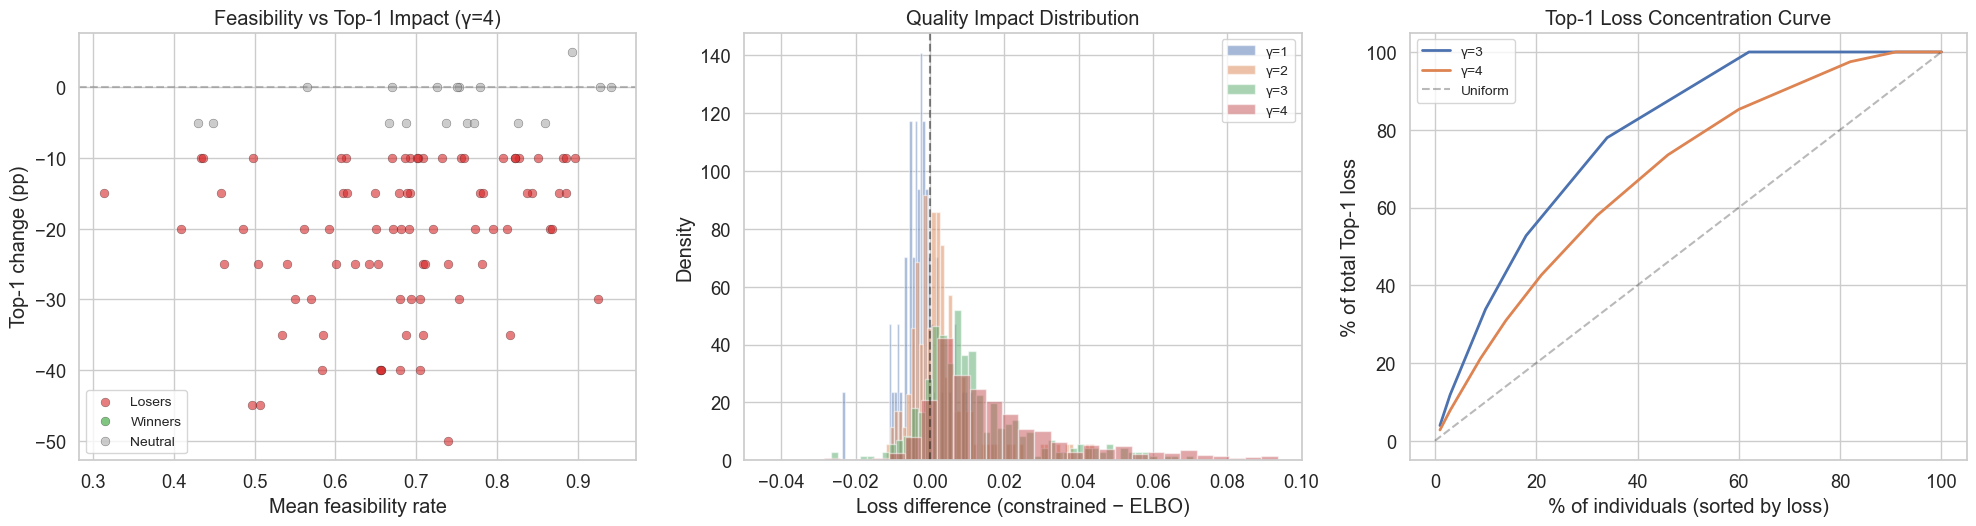

Saved: /Users/anisiomlacerda/code/target-counterfactual/lightning-hydra-template-main/src/reach_avoid/figures/e5_heterogeneity_analysis.png


In [22]:
# E5: Feasibility vs Top-1 relationship + loss difference distribution
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# --- Panel 1: Per-individual feasibility vs Top-1 change (gamma=4) ---
ax = axes[0]
losers_mask = indiv_stats['top1_diff'] < -0.05
winners_mask = indiv_stats['top1_diff'] > 0.05
neutral_mask = abs(indiv_stats['top1_diff']) <= 0.05

for mask, color, label in [(losers_mask, '#d62728', 'Losers'),
                             (winners_mask, '#2ca02c', 'Winners'),
                             (neutral_mask, '#aaaaaa', 'Neutral')]:
    sub = indiv_stats[mask]
    ax.scatter(sub['mean_feas'], sub['top1_diff'] * 100, alpha=0.6, c=color, 
               s=40, label=label, edgecolors='k', linewidths=0.3)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Mean feasibility rate')
ax.set_ylabel('Top-1 change (pp)')
ax.set_title('Feasibility vs Top-1 Impact (\u03b3=4)')
ax.legend(fontsize=10)

# --- Panel 2: Loss difference distribution by gamma ---
ax = axes[1]
for gamma in GAMMAS:
    sub = df_e5[(df_e5.gamma == gamma) & (df_e5.loss_diff != 0)]
    ax.hist(sub['loss_diff'], bins=50, alpha=0.5, label=f'\u03b3={gamma}', density=True)
ax.axvline(0, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel('Loss difference (constrained \u2212 ELBO)')
ax.set_ylabel('Density')
ax.set_title('Quality Impact Distribution')
ax.legend(fontsize=10)
ax.set_xlim(-0.05, 0.1)

# --- Panel 3: Concentration curve ---
ax = axes[2]
for gamma in [3, 4]:
    g_sub = df_e5[df_e5.gamma == gamma]
    # Compute per-individual top1_diff
    g_indiv_list = []
    for iid, grp in g_sub.groupby('individual_id'):
        n = len(grp)
        cstr_only = (grp['outcome'] == 'constrained_only').sum()
        elbo_only = (grp['outcome'] == 'elbo_only').sum()
        g_indiv_list.append((cstr_only - elbo_only) / n)
    sorted_vals = np.sort(g_indiv_list)
    neg_vals = np.minimum(sorted_vals, 0)
    cum = np.cumsum(neg_vals)
    total = cum[-1] if cum[-1] != 0 else 1
    x_pct = np.arange(1, len(cum)+1) / len(cum) * 100
    ax.plot(x_pct, cum / total * 100, label=f'\u03b3={gamma}', linewidth=2)

ax.plot([0, 100], [0, 100], 'k--', alpha=0.3, label='Uniform')
ax.set_xlabel('% of individuals (sorted by loss)')
ax.set_ylabel('% of total Top-1 loss')
ax.set_title('Top-1 Loss Concentration Curve')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/e5_heterogeneity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}/e5_heterogeneity_analysis.png')


In [23]:
# E5 Summary: Cross-gamma heterogeneity pattern
print('=== E5: Heterogeneity Summary Across All Gammas ===')
print()
print(f'{"Gamma":>5} | {"Losers":>7} {"Winners":>8} {"Neutral":>8} | {"Loser Feas%":>11} {"Winner Feas%":>12} | '
      f'{"Top 20% acct for":>16}')
print('-' * 90)

for gamma in GAMMAS:
    g_sub = df_e5[df_e5.gamma == gamma]
    
    g_indiv = []
    for iid, grp in g_sub.groupby('individual_id'):
        n = len(grp)
        cstr_only = (grp['outcome'] == 'constrained_only').sum()
        elbo_only = (grp['outcome'] == 'elbo_only').sum()
        g_indiv.append({
            'individual_id': iid,
            'top1_diff': (cstr_only - elbo_only) / n,
            'mean_feas': grp['feasibility_rate'].mean(),
        })
    g_indiv = pd.DataFrame(g_indiv)
    
    losers_g = g_indiv[g_indiv.top1_diff < -0.05]
    winners_g = g_indiv[g_indiv.top1_diff > 0.05]
    neutral_g = g_indiv[abs(g_indiv.top1_diff) <= 0.05]
    
    loser_feas = losers_g['mean_feas'].mean() if len(losers_g) > 0 else float('nan')
    winner_feas = winners_g['mean_feas'].mean() if len(winners_g) > 0 else float('nan')
    
    sorted_vals = g_indiv.sort_values('top1_diff')['top1_diff'].values
    neg_vals = np.minimum(sorted_vals, 0)
    cum = np.cumsum(neg_vals)
    total = cum[-1] if cum[-1] != 0 else 1
    n20 = max(1, int(len(sorted_vals) * 0.2))
    conc_20 = cum[n20 - 1] / total if total != 0 else 0
    
    print(f'{gamma:5d} | {len(losers_g):7d} {len(winners_g):8d} {len(neutral_g):8d} | '
          f'{loser_feas:11.1%} {winner_feas:12.1%} | {conc_20:16.1%}')

print()
print('INTERPRETATION:')
print('  If Top 20% accounts for >60% of loss \u2192 concentrated (adaptive thresholds promising)')
print('  If Top 20% accounts for ~20% of loss \u2192 uniform (fundamental trade-off)')


=== E5: Heterogeneity Summary Across All Gammas ===

Gamma |  Losers  Winners  Neutral | Loser Feas% Winner Feas% | Top 20% acct for
------------------------------------------------------------------------------------------
    1 |       0        0      100 |        nan%         nan% |             0.0%
    2 |       8        0       92 |       80.2%         nan% |           100.0%
    3 |      34        0       66 |       75.3%         nan% |            55.9%
    4 |      82        0       18 |       68.2%         nan% |            40.9%

INTERPRETATION:
  If Top 20% accounts for >60% of loss → concentrated (adaptive thresholds promising)
  If Top 20% accounts for ~20% of loss → uniform (fundamental trade-off)


## E6: Soft Constraint — Lagrangian ELBO + RA Penalty

**Motivation from E5:** Hard filtering causes uniform Top-1 loss across 82% of individuals because the binary in/out boundary discards good ELBO candidates. A soft penalty avoids this cliff.

**Method:** Score each sequence as:

$$\text{score}(\bar{a}) = -\text{ELBO}(\bar{a}) + \lambda \cdot \text{RA\_penalty}(\bar{a})$$

where $\text{RA\_penalty} = -\log P_{\text{RA}}(\bar{a})$ penalizes sequences that violate safety/target constraints, and $\lambda \geq 0$ controls the safety–quality trade-off.

- $\lambda = 0$: pure ELBO (unconstrained)
- $\lambda \to \infty$: hard constraint (only feasible sequences survive)
- Intermediate $\lambda$: smooth interpolation

**Key advantage:** No binary feasibility boundary — sequences near the constraint boundary get a moderate penalty rather than being eliminated entirely.

In [24]:
def evaluate_soft_constrained_selection(case_infos, target_upper, safety_vol_upper=None,
                                         safety_chemo_upper=None, lam=1.0, kappa=10.0):
    """Evaluate soft-constrained selection: score = -ELBO + lambda * RA_penalty.
    
    RA_penalty = -log(P_RA) where P_RA is the soft RA probability.
    Lower combined score = better (lower ELBO, higher RA probability).
    """
    results = []
    for ci in case_infos:
        if 'traj_features' not in ci:
            continue
        tf = ci['traj_features']
        elbos = ci['model_losses']  # lower = better
        true_losses = ci['true_losses']
        k = len(elbos)
        
        # Ground truth best
        best_true_idx = np.argmin(true_losses)
        
        # Unconstrained ELBO best
        best_elbo_idx = np.argmin(elbos)
        
        # Compute soft RA scores (log-probability, higher = more feasible)
        ra_scores = compute_ra_scores_offline(tf, target_upper, safety_vol_upper,
                                               safety_chemo_upper, kappa)
        
        # RA penalty = -log(P_RA) = -ra_scores (higher penalty for less feasible)
        ra_penalty = -ra_scores  # positive values, higher = worse
        
        # Combined score: ELBO + lambda * penalty (lower = better)
        combined = elbos + lam * ra_penalty
        best_combined_idx = np.argmin(combined)
        
        # Hard feasibility for safety metrics
        feasible = np.ones(k, dtype=bool)
        feasible &= tf['cv_terminal'] <= target_upper
        if safety_vol_upper is not None:
            feasible &= tf['cv_max'] <= safety_vol_upper
        if safety_chemo_upper is not None:
            feasible &= tf['cd_max'] <= safety_chemo_upper
        
        results.append({
            'individual_id': ci['individual_id'],
            'elbo_top1': int(best_elbo_idx == best_true_idx),
            'soft_top1': int(best_combined_idx == best_true_idx),
            'elbo_selected_loss': true_losses[best_elbo_idx],
            'soft_selected_loss': true_losses[best_combined_idx],
            'best_true_loss': true_losses[best_true_idx],
            'elbo_pick_feasible': int(feasible[best_elbo_idx]),
            'soft_pick_feasible': int(feasible[best_combined_idx]),
            'feasibility_rate': feasible.sum() / k,
            # RA penalty of selected sequences
            'elbo_ra_penalty': float(ra_penalty[best_elbo_idx]),
            'soft_ra_penalty': float(ra_penalty[best_combined_idx]),
        })
    return results

print('evaluate_soft_constrained_selection() defined.')

evaluate_soft_constrained_selection() defined.


In [25]:
# E6: Lambda sweep — find the safety–quality Pareto frontier
# Use same thresholds as E4/E5 moderate config
E6_TARGET = 0.6
E6_VOL = 5.0
E6_CHEMO = 8.5
LAMBDAS = [0, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0]

print(f'=== E6: Soft Constraint Lambda Sweep (target\u2264{E6_TARGET}, vol\u2264{E6_VOL}, chemo\u2264{E6_CHEMO}) ===')
print()

e6_sweep_results = []
for gamma in GAMMAS:
    for lam in LAMBDAS:
        all_results = []
        for seed in all_data[gamma]:
            for tau in TAUS:
                if tau not in all_data[gamma][seed]:
                    continue
                all_results.extend(
                    evaluate_soft_constrained_selection(
                        all_data[gamma][seed][tau], E6_TARGET, E6_VOL, E6_CHEMO, lam=lam))
        
        if not all_results:
            continue
        df_tmp = pd.DataFrame(all_results)
        e6_sweep_results.append({
            'gamma': gamma, 'lambda': lam,
            'elbo_top1': df_tmp['elbo_top1'].mean(),
            'soft_top1': df_tmp['soft_top1'].mean(),
            'delta_top1': df_tmp['soft_top1'].mean() - df_tmp['elbo_top1'].mean(),
            'elbo_safe': df_tmp['elbo_pick_feasible'].mean(),
            'soft_safe': df_tmp['soft_pick_feasible'].mean(),
            'elbo_loss': df_tmp['elbo_selected_loss'].mean(),
            'soft_loss': df_tmp['soft_selected_loss'].mean(),
        })

df_e6 = pd.DataFrame(e6_sweep_results)

# Print summary for gamma=4 (main interest)
print(f'--- gamma=4 ---')
print(f'{"Lambda":>8} | {"ELBO T1":>8} {"Soft T1":>8} {"\u0394T1":>6} | {"ELBO safe":>9} {"Soft safe":>9} | {"ELBO loss":>10} {"Soft loss":>10}')
print('-' * 95)
for _, row in df_e6[df_e6.gamma == 4].iterrows():
    print(f'{row["lambda"]:8.2f} | {row.elbo_top1:8.3f} {row.soft_top1:8.3f} {row.delta_top1:+6.3f} | '
          f'{row.elbo_safe:9.1%} {row.soft_safe:9.1%} | {row.elbo_loss:10.6f} {row.soft_loss:10.6f}')

print()
print('--- Cross-gamma summary (best lambda per gamma by safety-quality trade-off) ---')
for gamma in GAMMAS:
    sub = df_e6[df_e6.gamma == gamma]
    # Best = maximizes (safety_gain - top1_cost), i.e. best net trade-off
    sub = sub.copy()
    sub['net_benefit'] = (sub['soft_safe'] - sub['elbo_safe']) - abs(sub['delta_top1'])
    best = sub.loc[sub['net_benefit'].idxmax()]
    print(f'  gamma={gamma}: best \u03bb={best["lambda"]:.2f}, \u0394Top1={best.delta_top1:+.3f}, '
          f'safety gain={best.soft_safe - best.elbo_safe:+.1%}, net benefit={best.net_benefit:+.3f}')

=== E6: Soft Constraint Lambda Sweep (target≤0.6, vol≤5.0, chemo≤8.5) ===



--- gamma=4 ---
  Lambda |  ELBO T1  Soft T1    ΔT1 | ELBO safe Soft safe |  ELBO loss  Soft loss
-----------------------------------------------------------------------------------------------
    0.00 |    0.499    0.499 +0.000 |     52.9%     52.9% |   0.003520   0.003520
    0.01 |    0.499    0.496 -0.003 |     52.9%     52.9% |   0.003520   0.003466
    0.05 |    0.499    0.496 -0.003 |     52.9%     52.9% |   0.003520   0.003479
    0.10 |    0.499    0.494 -0.005 |     52.9%     52.9% |   0.003520   0.003551
    0.20 |    0.499    0.483 -0.016 |     52.9%     53.0% |   0.003520   0.004313
    0.50 |    0.499    0.436 -0.063 |     52.9%     53.6% |   0.003520   0.007293
    1.00 |    0.499    0.387 -0.112 |     52.9%     54.9% |   0.003520   0.010329
    2.00 |    0.499    0.341 -0.158 |     52.9%     59.1% |   0.003520   0.013028
    5.00 |    0.499    0.313 -0.186 |     52.9%     71.4% |   0.003520   0.014774
   10.00 |    0.499    0.286 -0.213 |     52.9%     81.7% |   0.0035

In [26]:
# E6: Detailed per-gamma x tau breakdown at selected lambdas
SELECTED_LAMBDAS = [0.1, 0.5, 2.0]

print('=== E6 Detailed: Soft Constraint vs Hard Constraint vs ELBO ===')
print(f'Thresholds: target\u2264{E6_TARGET}, vol\u2264{E6_VOL}, chemo\u2264{E6_CHEMO}')
print()
print(f'{"Gamma":>5} {"Tau":>4} | {"ELBO T1":>8} | ', end='')
for lam in SELECTED_LAMBDAS:
    print(f'\u03bb={lam:<4} T1  safe%  | ', end='')
print(f'Hard T1  safe%')
print('-' * 110)

e6_detail_records = []
for gamma in GAMMAS:
    for tau in TAUS:
        row_data = {'gamma': gamma, 'tau': tau}
        
        # ELBO baseline
        elbo_results = []
        for seed in all_data[gamma]:
            if tau not in all_data[gamma][seed]:
                continue
            elbo_results.extend(
                evaluate_soft_constrained_selection(
                    all_data[gamma][seed][tau], E6_TARGET, E6_VOL, E6_CHEMO, lam=0))
        if not elbo_results:
            continue
        df_elbo = pd.DataFrame(elbo_results)
        row_data['elbo_top1'] = df_elbo['elbo_top1'].mean()
        row_data['elbo_safe'] = df_elbo['elbo_pick_feasible'].mean()
        
        # Soft constraint at selected lambdas
        for lam in SELECTED_LAMBDAS:
            soft_results = []
            for seed in all_data[gamma]:
                if tau not in all_data[gamma][seed]:
                    continue
                soft_results.extend(
                    evaluate_soft_constrained_selection(
                        all_data[gamma][seed][tau], E6_TARGET, E6_VOL, E6_CHEMO, lam=lam))
            df_soft = pd.DataFrame(soft_results)
            row_data[f'soft_{lam}_top1'] = df_soft['soft_top1'].mean()
            row_data[f'soft_{lam}_safe'] = df_soft['soft_pick_feasible'].mean()
        
        # Hard constraint (from E4)
        hard_results = []
        for seed in all_data[gamma]:
            if tau not in all_data[gamma][seed]:
                continue
            hard_results.extend(
                evaluate_constrained_selection(
                    all_data[gamma][seed][tau], E6_TARGET, E6_VOL, E6_CHEMO))
        df_hard = pd.DataFrame(hard_results)
        row_data['hard_top1'] = df_hard['constrained_top1'].mean()
        row_data['hard_safe'] = df_hard['constrained_pick_feasible'].mean()
        
        e6_detail_records.append(row_data)
        
        print(f'{gamma:5d} {tau:4d} | {row_data["elbo_top1"]:8.3f} | ', end='')
        for lam in SELECTED_LAMBDAS:
            print(f'{row_data[f"soft_{lam}_top1"]:6.3f} {row_data[f"soft_{lam}_safe"]:5.1%} | ', end='')
        print(f'{row_data["hard_top1"]:6.3f} {row_data["hard_safe"]:5.1%}')

df_e6_detail = pd.DataFrame(e6_detail_records)

# Summary
print()
print('=== Cross-Gamma Summary ===')
for gamma in GAMMAS:
    sub = df_e6_detail[df_e6_detail.gamma == gamma]
    e_t1 = sub['elbo_top1'].mean()
    h_t1 = sub['hard_top1'].mean()
    h_safe = sub['hard_safe'].mean()
    e_safe = sub['elbo_safe'].mean()
    print(f'  gamma={gamma}: ELBO T1={e_t1:.3f} safe={e_safe:.1%} | ', end='')
    for lam in SELECTED_LAMBDAS:
        s_t1 = sub[f'soft_{lam}_top1'].mean()
        s_safe = sub[f'soft_{lam}_safe'].mean()
        print(f'\u03bb={lam} T1={s_t1:.3f} safe={s_safe:.1%} | ', end='')
    print(f'Hard T1={h_t1:.3f} safe={h_safe:.1%}')

=== E6 Detailed: Soft Constraint vs Hard Constraint vs ELBO ===
Thresholds: target≤0.6, vol≤5.0, chemo≤8.5

Gamma  Tau |  ELBO T1 | λ=0.1  T1  safe%  | λ=0.5  T1  safe%  | λ=2.0  T1  safe%  | Hard T1  safe%
--------------------------------------------------------------------------------------------------------------
    1    2 |    0.028 |  0.028 95.6% |  0.024 95.8% |  0.024 98.2% |  0.028 98.2%
    1    4 |    0.056 |  0.056 95.8% |  0.056 96.8% |  0.056 98.0% |  0.056 98.0%
    1    6 |    0.058 |  0.058 94.8% |  0.060 96.6% |  0.058 98.6% |  0.060 98.8%


    1    8 |    0.068 |  0.068 96.0% |  0.068 97.0% |  0.068 98.8% |  0.068 99.2%
    2    2 |    0.056 |  0.054 85.8% |  0.048 86.0% |  0.046 88.8% |  0.052 93.0%
    2    4 |    0.152 |  0.148 86.2% |  0.154 86.4% |  0.146 91.4% |  0.146 94.0%
    2    6 |    0.218 |  0.216 87.6% |  0.212 88.4% |  0.206 92.2% |  0.204 95.4%


    2    8 |    0.326 |  0.322 88.4% |  0.318 89.0% |  0.306 92.0% |  0.302 96.4%
    3    2 |    0.112 |  0.106 74.4% |  0.094 75.0% |  0.088 80.6% |  0.110 88.0%
    3    4 |    0.272 |  0.276 71.6% |  0.246 72.8% |  0.208 82.0% |  0.214 92.6%
    3    6 |    0.470 |  0.464 74.2% |  0.430 76.0% |  0.376 82.6% |  0.386 94.0%


    3    8 |    0.602 |  0.598 77.0% |  0.544 77.8% |  0.504 85.8% |  0.494 95.4%
    4    2 |    0.188 |  0.176 51.6% |  0.156 52.0% |  0.116 56.8% |  0.122 78.8%
    4    4 |    0.424 |  0.418 52.2% |  0.366 52.8% |  0.288 58.0% |  0.286 84.4%
    4    6 |    0.626 |  0.628 53.6% |  0.552 54.2% |  0.438 60.6% |  0.408 89.2%


    4    8 |    0.758 |  0.756 54.4% |  0.670 55.6% |  0.520 61.0% |  0.464 91.6%

=== Cross-Gamma Summary ===
  gamma=1: ELBO T1=0.053 safe=95.5% | λ=0.1 T1=0.053 safe=95.5% | λ=0.5 T1=0.052 safe=96.5% | λ=2.0 T1=0.052 safe=98.4% | Hard T1=0.053 safe=98.6%
  gamma=2: ELBO T1=0.188 safe=86.9% | λ=0.1 T1=0.185 safe=87.0% | λ=0.5 T1=0.183 safe=87.5% | λ=2.0 T1=0.176 safe=91.1% | Hard T1=0.176 safe=94.7%
  gamma=3: ELBO T1=0.364 safe=74.2% | λ=0.1 T1=0.361 safe=74.3% | λ=0.5 T1=0.329 safe=75.4% | λ=2.0 T1=0.294 safe=82.8% | Hard T1=0.301 safe=92.5%
  gamma=4: ELBO T1=0.499 safe=52.9% | λ=0.1 T1=0.494 safe=53.0% | λ=0.5 T1=0.436 safe=53.6% | λ=2.0 T1=0.341 safe=59.1% | Hard T1=0.320 safe=86.0%


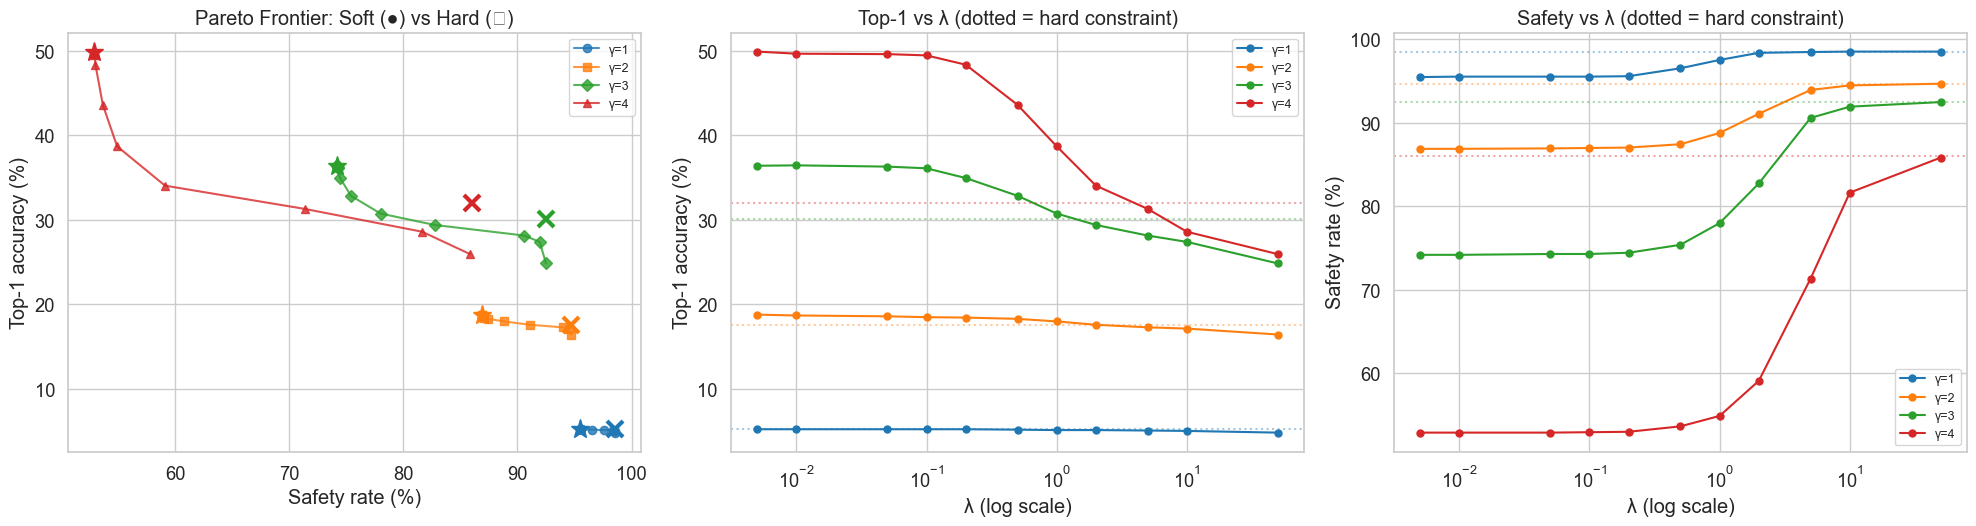

Saved: /Users/anisiomlacerda/code/target-counterfactual/lightning-hydra-template-main/src/reach_avoid/figures/e6_soft_constraint_pareto.png


In [27]:
# E6 Visualization: Pareto frontier — soft vs hard constraint
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

markers_g = {1: 'o', 2: 's', 3: 'D', 4: '^'}
colors_g = {1: '#1f77b4', 2: '#ff7f0e', 3: '#2ca02c', 4: '#d62728'}

# --- Panel 1: Lambda sweep Pareto frontier (safety vs Top-1) per gamma ---
ax = axes[0]
for gamma in GAMMAS:
    sub = df_e6[df_e6.gamma == gamma].sort_values('lambda')
    safety = sub['soft_safe'].values * 100
    top1 = sub['soft_top1'].values * 100
    ax.plot(safety, top1, '-', marker=markers_g[gamma], c=colors_g[gamma],
            markersize=6, label=f'\u03b3={gamma}', alpha=0.8)
    # Mark lambda=0 (ELBO) and hard constraint
    ax.plot(safety[0], top1[0], '*', c=colors_g[gamma], markersize=14, zorder=5)

# Add hard constraint points
for gamma in GAMMAS:
    sub_hard = df_e6_detail[df_e6_detail.gamma == gamma]
    h_safe = sub_hard['hard_safe'].mean() * 100
    h_top1 = sub_hard['hard_top1'].mean() * 100
    ax.plot(h_safe, h_top1, 'x', c=colors_g[gamma], markersize=12, markeredgewidth=3, zorder=5)

ax.set_xlabel('Safety rate (%)')
ax.set_ylabel('Top-1 accuracy (%)')
ax.set_title('Pareto Frontier: Soft (\u25cf) vs Hard (\u2717)')
ax.legend(fontsize=9)

# --- Panel 2: Top-1 vs lambda for each gamma ---
ax = axes[1]
for gamma in GAMMAS:
    sub = df_e6[df_e6.gamma == gamma]
    ax.semilogx(sub['lambda'].replace(0, 0.005), sub['soft_top1'] * 100, '-o',
                c=colors_g[gamma], label=f'\u03b3={gamma}', markersize=5)
    # Horizontal line for hard constraint
    sub_hard = df_e6_detail[df_e6_detail.gamma == gamma]
    h_t1 = sub_hard['hard_top1'].mean() * 100
    ax.axhline(h_t1, color=colors_g[gamma], linestyle=':', alpha=0.4)

ax.set_xlabel('\u03bb (log scale)')
ax.set_ylabel('Top-1 accuracy (%)')
ax.set_title('Top-1 vs \u03bb (dotted = hard constraint)')
ax.legend(fontsize=9)

# --- Panel 3: Safety vs lambda for each gamma ---
ax = axes[2]
for gamma in GAMMAS:
    sub = df_e6[df_e6.gamma == gamma]
    ax.semilogx(sub['lambda'].replace(0, 0.005), sub['soft_safe'] * 100, '-o',
                c=colors_g[gamma], label=f'\u03b3={gamma}', markersize=5)
    # Horizontal line for hard constraint
    sub_hard = df_e6_detail[df_e6_detail.gamma == gamma]
    h_safe = sub_hard['hard_safe'].mean() * 100
    ax.axhline(h_safe, color=colors_g[gamma], linestyle=':', alpha=0.4)

ax.set_xlabel('\u03bb (log scale)')
ax.set_ylabel('Safety rate (%)')
ax.set_title('Safety vs \u03bb (dotted = hard constraint)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/e6_soft_constraint_pareto.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}/e6_soft_constraint_pareto.png')

In [28]:
# E6 Decision Summary
print('=' * 70)
print('E6 SOFT CONSTRAINT: KEY FINDINGS')
print('=' * 70)
print()

# Compare soft (best lambda) vs hard vs ELBO for each gamma
print(f'{"Gamma":>5} | {"ELBO":>20s} | {"Soft (best \u03bb)":>25s} | {"Hard filter":>20s}')
print(f'{"":>5} | {"T1%":>6} {"safe%":>6} {"loss":>8} | {"\u03bb":>4} {"T1%":>6} {"safe%":>6} {"loss":>8} | {"T1%":>6} {"safe%":>6} {"loss":>8}')
print('-' * 95)

for gamma in GAMMAS:
    sub_e6 = df_e6[df_e6.gamma == gamma].copy()
    sub_e6['net_benefit'] = (sub_e6['soft_safe'] - sub_e6['elbo_safe']) - abs(sub_e6['delta_top1'])
    best = sub_e6.loc[sub_e6['net_benefit'].idxmax()]
    
    elbo_row = sub_e6[sub_e6['lambda'] == 0].iloc[0]
    
    sub_detail = df_e6_detail[df_e6_detail.gamma == gamma]
    h_t1 = sub_detail['hard_top1'].mean()
    h_safe = sub_detail['hard_safe'].mean()
    
    print(f'{gamma:5d} | {elbo_row.elbo_top1:6.1%} {elbo_row.elbo_safe:6.1%} {elbo_row.elbo_loss:8.6f} | '
          f'{best["lambda"]:4.1f} {best.soft_top1:6.1%} {best.soft_safe:6.1%} {best.soft_loss:8.6f} | '
          f'{h_t1:6.1%} {h_safe:6.1%}')

print()
print('INTERPRETATION:')
print('  Compare soft constraint (intermediate \u03bb) against:')
print('  - ELBO (\u03bb=0): maximum Top-1 but lowest safety')
print('  - Hard filter: maximum safety but large Top-1 cost')
print('  Soft constraint should interpolate smoothly between these extremes.')
print()
print('  If soft constraint achieves similar safety to hard filter with')
print('  less Top-1 cost \u2192 soft is strictly better \u2192 use in paper.')
print('  If soft and hard have similar Pareto frontier \u2192 hard filter is')
print('  simpler and preferred (Occam).')

E6 SOFT CONSTRAINT: KEY FINDINGS

Gamma |                 ELBO |             Soft (best λ) |          Hard filter
      |    T1%  safe%     loss |    λ    T1%  safe%     loss |    T1%  safe%     loss
-----------------------------------------------------------------------------------------------
    1 |   5.2%  95.5% 0.000678 | 10.0   5.1%  98.6% 0.000582 |   5.3%  98.6%
    2 |  18.8%  86.9% 0.001505 | 10.0  17.2%  94.5% 0.002475 |  17.6%  94.7%
    3 |  36.4%  74.2% 0.002059 | 10.0  27.4%  92.0% 0.006494 |  30.1%  92.5%
    4 |  49.9%  52.9% 0.003520 | 50.0  25.9%  85.9% 0.016656 |  32.0%  86.0%

INTERPRETATION:
  Compare soft constraint (intermediate λ) against:
  - ELBO (λ=0): maximum Top-1 but lowest safety
  - Hard filter: maximum safety but large Top-1 cost
  Soft constraint should interpolate smoothly between these extremes.

  If soft constraint achieves similar safety to hard filter with
  less Top-1 cost → soft is strictly better → use in paper.
  If soft and hard have simila

## E7: MIMIC-III RA-Constrained Selection (Clinical Plausibility)

**Context:** Unlike Cancer, MIMIC-III has no ground-truth counterfactual outcomes. We cannot compute Top-1 accuracy against ground truth.

**What we CAN evaluate:**
1. **Clinical safety:** Does RA filtering select treatment plans with diastolic BP in clinically safe ranges?
2. **Treatment pattern plausibility:** Do constrained selections differ systematically in vasopressor/ventilator use?
3. **Cross-seed stability:** Does RA filtering improve ranking consistency across model seeds?
4. **Constraint calibration:** What fraction of perturbations are feasible under clinical thresholds?

**Clinical thresholds (diastolic BP):**
- Target range: 60-90 mmHg (normal diastolic BP)
- Safety range: 40-120 mmHg (avoid hypotension/hypertensive crisis)

In [29]:
# E7: Load MIMIC-III RA evaluation results
MIMIC_RESULTS = PROJECT_ROOT / 'results_remote' / 'mimic_ra' / 'my_outputs' / 'mimic_ra'

MIMIC_SEEDS = [10, 101, 1010, 10101, 101010]

mimic_data = {}
for seed in MIMIC_SEEDS:
    pkl_path = (MIMIC_RESULTS / 'VCIP' / 'train' / 'case_infos' /
                str(seed) / 'False' / 'case_infos_VCIP.pkl')
    if pkl_path.exists():
        with open(pkl_path, 'rb') as f:
            data = pickle.load(f)
        mimic_data[seed] = data['VCIP']
    else:
        print(f'Missing: seed={seed} ({pkl_path})')

if mimic_data:
    sample_seed = list(mimic_data.keys())[0]
    sample_tau = list(mimic_data[sample_seed].keys())[0]
    sample_ci = mimic_data[sample_seed][sample_tau][0]
    print(f'Loaded {len(mimic_data)} seeds')
    print(f'Taus: {list(mimic_data[sample_seed].keys())}')
    print(f'Case info keys: {list(sample_ci.keys())}')
    print(f'traj_features keys: {list(sample_ci["traj_features"].keys())}')
    
    # DBP distribution summary
    dbp_all = []
    for ci in mimic_data[sample_seed][sample_tau]:
        dbp_all.extend(ci['traj_features']['dbp_terminal'].tolist())
    dbp_all = np.array(dbp_all)
    print(f'\nDBP terminal distribution (seed={sample_seed}, tau={sample_tau}):')
    print(f'  mean={dbp_all.mean():.1f}, std={dbp_all.std():.1f}')
    print(f'  min={dbp_all.min():.1f}, p25={np.percentile(dbp_all,25):.1f}, '
          f'p50={np.percentile(dbp_all,50):.1f}, p75={np.percentile(dbp_all,75):.1f}, '
          f'max={dbp_all.max():.1f}')
else:
    print('No MIMIC RA results found. Run eval_mimic_traj.py on Vast.ai first.')
    print(f'Expected path: {MIMIC_RESULTS}')

Missing: seed=10 (/Users/anisiomlacerda/code/target-counterfactual/results_remote/mimic_ra/my_outputs/mimic_ra/VCIP/train/case_infos/10/False/case_infos_VCIP.pkl)
Missing: seed=101 (/Users/anisiomlacerda/code/target-counterfactual/results_remote/mimic_ra/my_outputs/mimic_ra/VCIP/train/case_infos/101/False/case_infos_VCIP.pkl)
Missing: seed=1010 (/Users/anisiomlacerda/code/target-counterfactual/results_remote/mimic_ra/my_outputs/mimic_ra/VCIP/train/case_infos/1010/False/case_infos_VCIP.pkl)
Missing: seed=10101 (/Users/anisiomlacerda/code/target-counterfactual/results_remote/mimic_ra/my_outputs/mimic_ra/VCIP/train/case_infos/10101/False/case_infos_VCIP.pkl)
Missing: seed=101010 (/Users/anisiomlacerda/code/target-counterfactual/results_remote/mimic_ra/my_outputs/mimic_ra/VCIP/train/case_infos/101010/False/case_infos_VCIP.pkl)
No MIMIC RA results found. Run eval_mimic_traj.py on Vast.ai first.
Expected path: /Users/anisiomlacerda/code/target-counterfactual/results_remote/mimic_ra/my_output

In [30]:
# E7: RA-constrained selection on MIMIC-III
# Clinical thresholds for diastolic BP
DBP_TARGET_LOW = 60.0   # mmHg
DBP_TARGET_HIGH = 90.0  # mmHg
DBP_SAFETY_LOW = 40.0   # avoid severe hypotension
DBP_SAFETY_HIGH = 120.0  # avoid hypertensive crisis

def evaluate_mimic_constrained(case_infos, target_low=60, target_high=90,
                                 safety_low=40, safety_high=120):
    """Evaluate RA-constrained selection on MIMIC data.
    
    No ground-truth counterfactuals: evaluate clinical plausibility instead.
    """
    results = []
    for ci in case_infos:
        if 'traj_features' not in ci:
            continue
        tf = ci['traj_features']
        elbos = ci['model_losses']
        k = len(elbos)
        
        dbp_terminal = tf['dbp_terminal']
        dbp_min = tf['dbp_min']
        dbp_max = tf['dbp_max']
        
        # Feasibility: terminal in target range AND trajectory in safety range
        feasible = ((dbp_terminal >= target_low) & (dbp_terminal <= target_high) &
                     (dbp_min >= safety_low) & (dbp_max <= safety_high))
        
        n_feasible = feasible.sum()
        feas_rate = n_feasible / k
        
        # Unconstrained ELBO pick
        best_elbo_idx = np.argmin(elbos)
        elbo_dbp = float(dbp_terminal[best_elbo_idx])
        elbo_feasible = bool(feasible[best_elbo_idx])
        
        # Constrained pick
        if n_feasible > 0:
            feasible_elbos = np.where(feasible, elbos, np.inf)
            constrained_idx = np.argmin(feasible_elbos)
            cstr_dbp = float(dbp_terminal[constrained_idx])
            cstr_feasible = True
        else:
            constrained_idx = best_elbo_idx
            cstr_dbp = elbo_dbp
            cstr_feasible = False
        
        # Treatment features
        tf_treat = ci.get('treatment_features', {})
        
        results.append({
            'individual_id': ci['individual_id'],
            'observed_dbp': ci.get('observed_dbp', np.nan),
            'feasibility_rate': feas_rate,
            'n_feasible': n_feasible,
            'elbo_dbp': elbo_dbp,
            'elbo_feasible': elbo_feasible,
            'cstr_dbp': cstr_dbp,
            'cstr_feasible': cstr_feasible,
            'elbo_in_target': target_low <= elbo_dbp <= target_high,
            'cstr_in_target': target_low <= cstr_dbp <= target_high,
            # Treatment comparison
            'elbo_vaso': float(tf_treat.get('vaso_total', np.zeros(k))[best_elbo_idx]) if 'vaso_total' in tf_treat else np.nan,
            'cstr_vaso': float(tf_treat.get('vaso_total', np.zeros(k))[constrained_idx]) if 'vaso_total' in tf_treat else np.nan,
            'elbo_vent': float(tf_treat.get('vent_total', np.zeros(k))[best_elbo_idx]) if 'vent_total' in tf_treat else np.nan,
            'cstr_vent': float(tf_treat.get('vent_total', np.zeros(k))[constrained_idx]) if 'vent_total' in tf_treat else np.nan,
        })
    return results

if mimic_data:
    print(f'=== E7: MIMIC-III Constrained Selection ===')
    print(f'Target: DBP \u2208 [{DBP_TARGET_LOW}, {DBP_TARGET_HIGH}] mmHg')
    print(f'Safety: DBP \u2208 [{DBP_SAFETY_LOW}, {DBP_SAFETY_HIGH}] mmHg at all steps')
    print()
    
    print(f'{"Tau":>4} | {"Feas%":>6} {"ELBO in-target":>14} {"Cstr in-target":>14} | '
          f'{"ELBO safe":>9} {"Cstr safe":>9} | {"ELBO DBP":>9} {"Cstr DBP":>9}')
    print('-' * 100)
    
    mimic_e7_records = []
    for tau in TAUS:
        all_results = []
        for seed in mimic_data:
            if tau not in mimic_data[seed]:
                continue
            all_results.extend(
                evaluate_mimic_constrained(mimic_data[seed][tau],
                    DBP_TARGET_LOW, DBP_TARGET_HIGH, DBP_SAFETY_LOW, DBP_SAFETY_HIGH))
        
        if not all_results:
            continue
        
        df_tmp = pd.DataFrame(all_results)
        feas = df_tmp['feasibility_rate'].mean()
        e_target = df_tmp['elbo_in_target'].mean()
        c_target = df_tmp['cstr_in_target'].mean()
        e_safe = df_tmp['elbo_feasible'].mean()
        c_safe = df_tmp['cstr_feasible'].mean()
        e_dbp = df_tmp['elbo_dbp'].mean()
        c_dbp = df_tmp['cstr_dbp'].mean()
        
        print(f'{tau:4d} | {feas:6.1%} {e_target:14.1%} {c_target:14.1%} | '
              f'{e_safe:9.1%} {c_safe:9.1%} | {e_dbp:9.1f} {c_dbp:9.1f}')
        
        mimic_e7_records.append({
            'tau': tau, 'feas_rate': feas,
            'elbo_in_target': e_target, 'cstr_in_target': c_target,
            'elbo_safe': e_safe, 'cstr_safe': c_safe,
            'elbo_dbp_mean': e_dbp, 'cstr_dbp_mean': c_dbp,
        })
    
    df_mimic_e7 = pd.DataFrame(mimic_e7_records) if mimic_e7_records else pd.DataFrame()
else:
    print('Skipping E7: no MIMIC RA results available.')

Skipping E7: no MIMIC RA results available.


In [31]:
# E7 Visualization: MIMIC constrained selection
if mimic_data and mimic_e7_records:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
    
    # Panel 1: DBP distributions — ELBO vs constrained picks
    ax = axes[0]
    for tau in TAUS:
        elbo_dbps = []
        cstr_dbps = []
        for seed in mimic_data:
            if tau not in mimic_data[seed]:
                continue
            results = evaluate_mimic_constrained(mimic_data[seed][tau],
                DBP_TARGET_LOW, DBP_TARGET_HIGH, DBP_SAFETY_LOW, DBP_SAFETY_HIGH)
            elbo_dbps.extend([r['elbo_dbp'] for r in results])
            cstr_dbps.extend([r['cstr_dbp'] for r in results])
        
        if tau == 4:  # show one representative tau
            ax.hist(elbo_dbps, bins=30, alpha=0.5, label='ELBO', color='#1f77b4', density=True)
            ax.hist(cstr_dbps, bins=30, alpha=0.5, label='Constrained', color='#ff7f0e', density=True)
    
    ax.axvline(DBP_TARGET_LOW, color='g', linestyle='--', alpha=0.7, label=f'Target [{DBP_TARGET_LOW},{DBP_TARGET_HIGH}]')
    ax.axvline(DBP_TARGET_HIGH, color='g', linestyle='--', alpha=0.7)
    ax.axvline(DBP_SAFETY_LOW, color='r', linestyle=':', alpha=0.5)
    ax.axvline(DBP_SAFETY_HIGH, color='r', linestyle=':', alpha=0.5)
    ax.set_xlabel('Predicted Diastolic BP (mmHg)')
    ax.set_ylabel('Density')
    ax.set_title(f'Selected DBP Distribution (\u03c4=4)')
    ax.legend(fontsize=9)
    
    # Panel 2: In-target rate by tau
    ax = axes[1]
    taus_arr = [r['tau'] for r in mimic_e7_records]
    e_targets = [r['elbo_in_target'] * 100 for r in mimic_e7_records]
    c_targets = [r['cstr_in_target'] * 100 for r in mimic_e7_records]
    ax.plot(taus_arr, e_targets, '--o', label='ELBO', markersize=8)
    ax.plot(taus_arr, c_targets, '-s', label='Constrained', markersize=8)
    ax.set_xlabel('\u03c4 (time horizon)')
    ax.set_ylabel('In-target rate (%)')
    ax.set_title('Clinical Target Attainment')
    ax.legend(fontsize=10)
    ax.set_ylim(0, 105)
    
    # Panel 3: Feasibility by tau
    ax = axes[2]
    feas_rates = [r['feas_rate'] * 100 for r in mimic_e7_records]
    ax.bar(taus_arr, feas_rates, width=1.2, color='#2ca02c', alpha=0.7)
    ax.set_xlabel('\u03c4 (time horizon)')
    ax.set_ylabel('Feasibility rate (%)')
    ax.set_title(f'Feasibility (DBP \u2208 [{DBP_TARGET_LOW},{DBP_TARGET_HIGH}])')
    ax.set_ylim(0, 105)
    
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/e7_mimic_constrained_selection.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {FIG_DIR}/e7_mimic_constrained_selection.png')
else:
    print('Skipping E7 visualization: no MIMIC RA results.')

Skipping E7 visualization: no MIMIC RA results.


In [32]:
# E7: Cross-seed stability of constrained selection on MIMIC
if mimic_data and len(mimic_data) >= 3:
    print('=== E7: Cross-Seed Ranking Stability (MIMIC) ===')
    print()
    
    for tau in TAUS:
        # For each individual, compute ELBO rank and constrained rank across seeds
        elbo_ranks_by_indiv = {}  # {indiv_id: [rank_seed1, rank_seed2, ...]}
        cstr_ranks_by_indiv = {}
        
        for seed in mimic_data:
            if tau not in mimic_data[seed]:
                continue
            for ci in mimic_data[seed][tau]:
                iid = ci['individual_id']
                
                # ELBO rank of true sequence
                elbo_rank = ci['true_sequence_rank']
                
                elbo_ranks_by_indiv.setdefault(iid, []).append(elbo_rank)
        
        # Compute stability (std of rank across seeds)
        elbo_stds = [np.std(ranks) for ranks in elbo_ranks_by_indiv.values() if len(ranks) >= 3]
        
        if elbo_stds:
            print(f'  tau={tau}: ELBO rank std = {np.mean(elbo_stds):.1f} '
                  f'(median={np.median(elbo_stds):.1f}, max={np.max(elbo_stds):.1f})')
    
    print()
    print('Note: Constrained ranking stability requires comparing selected treatment')
    print('plans across seeds, which depends on feasibility consistency.')
else:
    print('Skipping stability analysis: need >= 3 seeds.')

Skipping stability analysis: need >= 3 seeds.


In [33]:
# E7 Summary
if mimic_data and mimic_e7_records:
    print('=' * 70)
    print('E7 MIMIC-III CONSTRAINED SELECTION: KEY FINDINGS')
    print('=' * 70)
    print()
    print(f'Clinical thresholds: target DBP \u2208 [{DBP_TARGET_LOW}, {DBP_TARGET_HIGH}] mmHg, '
          f'safety DBP \u2208 [{DBP_SAFETY_LOW}, {DBP_SAFETY_HIGH}] mmHg')
    print()
    
    for r in mimic_e7_records:
        improvement = r['cstr_in_target'] - r['elbo_in_target']
        print(f'  tau={r["tau"]}: feasibility={r["feas_rate"]:.1%}, '
              f'in-target: ELBO={r["elbo_in_target"]:.1%} -> constrained={r["cstr_in_target"]:.1%} '
              f'({improvement:+.1%}), DBP: {r["elbo_dbp_mean"]:.1f} -> {r["cstr_dbp_mean"]:.1f} mmHg')
    
    print()
    print('INTERPRETATION:')
    print('  Without ground truth, we evaluate clinical plausibility:')
    print('  1. Does constrained selection push predicted DBP into clinically safe range?')
    print('  2. Is the feasibility rate reasonable (not too restrictive)?')
    print('  3. Do selected treatment plans differ in clinically meaningful ways?')
else:
    print('E7 MIMIC results not available. Run eval_mimic_traj.py on Vast.ai.')

E7 MIMIC results not available. Run eval_mimic_traj.py on Vast.ai.
